# 015. 長文脈拡張 / Long Context Extension

## 1. 概要 / Overview

RoPE(Rotary Position Embedding、回転位置エンコーディング)で学習したモデルは、学習時の文脈長 $L$ を超える位置で
予測が急に悪化する。本トピックは、**RoPE で学習済みのモデルに後から手を加えて文脈長を伸ばす技術**(位置補間、
NTK-aware スケーリング、NTK-by-parts、YaRN、dynamic scaling、底の調整)を扱い、「学習長を超えると何が壊れるか、
各手法はそれをどう直すか、伸ばした文脈は実際に使われるか」を、008 で事前学習した小型 GPT で検証する。

[003](../01_foundations/003_positional_encoding_rope.ipynb) との違い: 003 は **学習の時点から** 位置エンコーディングの
方式を変えて、学習長を超える外挿の性能を方式間で比べた。本トピックは方式を RoPE に固定し、**学習済みのモデルの RoPE の
周波数を推論時(または短い微調整)で変える** ことで文脈長を伸ばす。

## 2. 参考論文 / References

1. Su, J., Ahmed, M., Lu, Y., Pan, S., Bo, W., Liu, Y., "RoFormer: Enhanced Transformer with Rotary Position Embedding",
   Neurocomputing 568, 2024. https://arxiv.org/abs/2104.09864
   ([003](../01_foundations/003_positional_encoding_rope.ipynb) と同じ。RoPE の定義、3.1 節)
2. Chen, S., Wong, S., Chen, L., Tian, Y., "Extending Context Window of Large Language Models via Positional
   Interpolation", arXiv 2023. https://arxiv.org/abs/2306.15595
   (位置補間。Attention のスコアの補間の上界(定理 2.1)と外挿の上界の比較、3.3 節)
3. bloc97, "NTK-Aware Scaled RoPE allows LLaMA models to have extended (8k+) context size without any fine-tuning
   and minimal perplexity degradation", Reddit(r/LocalLLaMA)への投稿, 2023.
   https://www.reddit.com/r/LocalLLaMA/comments/14lz7j5/ntkaware_scaled_rope_allows_llama_models_to_have/
   (NTK-aware スケーリングの初出。論文ではないため、式と導出は [4] の 3.1 節と Appendix A.1 の記述に従う、3.4 節)
4. Peng, B., Quesnelle, J., Fan, H., Shippole, E., "YaRN: Efficient Context Window Extension of Large Language Models",
   ICLR 2024. https://arxiv.org/abs/2309.00071(https://openreview.net/forum?id=wHBfxhZu1u)
   (NTK-aware の定式化(3.1 節)、NTK-by-parts(3.2 節)、dynamic scaling と KV キャッシュの注意(3.3 節)、
   YaRN の温度の補正(3.4 節)。本ノートブックの 3.4〜3.7 節)
5. Xiong, W., Liu, J., Molybog, I., Zhang, H., Bhargava, P., et al., "Effective Long-Context Scaling of Foundation
   Models", NAACL 2024. https://arxiv.org/abs/2309.16039(https://aclanthology.org/2024.naacl-long.260/)
   (底の調整(Adjusted Base Frequency、ABF)。底を 10,000 から 500,000 にして長い系列で継続事前学習する、3.8 節)
6. Ding, Y., Zhang, L. L., Zhang, C., Xu, Y., Shang, N., Xu, J., Yang, F., Yang, M., "LongRoPE: Extending LLM Context
   Window Beyond 2 Million Tokens", ICML 2024. https://arxiv.org/abs/2402.13753
   (https://proceedings.mlr.press/v235/ding24i.html)(次元ごとの倍率の探索。位置づけのみ、3.9 節)
7. Qwen Team, "Qwen3 Technical Report", arXiv 2025. https://arxiv.org/abs/2505.09388 、および Qwen3 のモデルカード
   (例: https://huggingface.co/Qwen/Qwen3-8B)
   (実務での使われ方: 事前学習の長文脈の段階での ABF(底を 10,000 から 1,000,000 へ)と文脈長 32,768、推論時の
   YaRN(`rope_scaling`の`factor`が 4.0)、静的な YaRN が短い入力の性能に影響しうるという注意、3.8 節)
8. Dao, T., Fu, D. Y., Ermon, S., Rudra, A., Ré, C., "FlashAttention: Fast and Memory-Efficient Exact Attention
   with IO-Awareness", NeurIPS 2022. https://arxiv.org/abs/2205.14135
   ([014](014_flash_attention.ipynb) と同じ。伸ばした文脈での Attention のメモリ、3.10 節)

## 3. 理論 / Theory

### 3.0 記号

記号は原論文 [1][4] に従う。

- $d$: 1 ヘッドあたりの次元([001](../01_foundations/001_attention_mechanism.ipynb) の $d_k$)。YaRN の原論文 [4] の
  $|D|$ にあたる。RoPE は $d$ 次元を $d/2$ 個の 2 次元の部分空間に分けて回転させる。
- $i = 0, 1, \dots, d/2 - 1$: 部分空間の番号。
- $b$: 角周波数の底(base)。008 のモデルでは $b = 10000$。
- $\theta_i = b^{-2i/d}$: 部分空間 $i$ の角周波数(1 位置進むごとの回転角)。$\lambda_i = 2\pi / \theta_i$: 部分空間 $i$ の
  波長(1 周するのに要する位置の数)。
- $m, n$: Query と Key の位置(0 始まり)。
- $L$: 学習時の文脈長(008 のモデルでは $L = 256$)。[014](014_flash_attention.ipynb) では $L$ を logsumexp の記号に
  使ったが、本ノートブックの $L$ は文脈長である。
- $L'$: 伸ばした後の文脈長。$s = L' / L$: 拡張の倍率(scale factor)。
- $l$: 現在処理している系列の長さ(dynamic scaling で使う)。
- $\theta'_i$: 各手法で変換した後の角周波数。$b'$: 変換後の底。
- $r_i = L / \lambda_i$: 学習時の文脈長の中に部分空間 $i$ の波長が何周分入るか。$\alpha, \beta$: NTK-by-parts の境界。
  $\gamma(r)$: ランプ関数。
- $t$: Attention の温度(YaRN)。

### 3.1 RoPE の周波数と波長

RoPE [1] は、位置 $m$ の Query $q$ の部分空間 $i$ の 2 成分を角度 $m \theta_i$ だけ回転させ、Key も同様に位置 $n$ で
回転させる([003](../01_foundations/003_positional_encoding_rope.ipynb))。部分空間 $i$ の 2 成分を複素数
$q^{(i)}, k^{(i)}$ とみなすと、内積は

$$
q_m^\top k_n = \mathrm{Re} \sum_{i=0}^{d/2-1} q^{(i)} \overline{k^{(i)}}\, e^{\mathrm{i}\,(m-n)\,\theta_i}
$$

となり($\mathrm{i}$ は虚数単位、$\overline{\cdot}$ は複素共役)、位置は相対位置 $m - n$ を通じてのみ現れる。

角周波数 $\theta_i = b^{-2i/d}$ は $i = 0$ の $1$ から $i = d/2 - 1$ の $b^{-(d-2)/d}$ まで等比で下がる。波長
$\lambda_i = 2\pi b^{2i/d}$ は $2\pi$ から約 $2\pi b$ まで伸びる。**番号の小さい部分空間は高周波(波長が短い)、
大きい部分空間は低周波(波長が長い)** である。

本トピックのモデル($d = 32$、$b = 10000$、$L = 256$)では $\lambda_i = 2\pi \cdot 10000^{i/16}$ なので、
$\lambda_i < L$ となるのは $i \le 6$ の 7 個、$\lambda_i > L$ となるのは $i \ge 7$ の 9 個である(5.6 節で表として印字する)。

### 3.2 学習長を超えると何が壊れるか

長さ $L$ の系列で学習すると、モデルが見る相対位置は $0 \le m - n \le L - 1$ に限られる。部分空間 $i$ の回転角
$(m - n)\theta_i$ は、学習中に $[0, (L-1)\theta_i]$ の範囲しか現れない。

- **高周波の部分空間**($\lambda_i \le L$): 学習中に回転角が 1 周以上回るので、$2\pi$ を法として全ての角度を見ている。
  $L$ を超える相対位置でも、個々の部分空間の回転角そのものは見たことのある値になる。
- **低周波の部分空間**($\lambda_i > L$): 回転角は $[0, 2\pi)$ の一部 $[0, 2\pi L / \lambda_i)$ にしか現れない。$L$ を超える
  相対位置では、**学習中に一度も見たことのない回転角** が現れる。Query・Key の重みはこの範囲の外での振る舞いを
  制約されていないので、Attention のスコアが学習中にはなかった値をとりうる。

位置補間の原論文 [2] は、スコアを相対位置 $s$ の関数(この段落の $s$ は倍率ではなく相対位置で、原論文の記号である)

$$
a(s) = \mathrm{Re} \sum_{j=0}^{d/2-1} h_j\, e^{\mathrm{i}\, s \theta_j}
$$

($h_j$ は Query と Key から決まる複素係数)とみなし、三角関数の和は $[0, L]$ で小さい値に収まっていても、その外では
いくらでも大きな値をとりうることを示した(外挿の上界は緩い)。このため、学習長を超える位置では Attention の重みが
学習中にはない分布になり、予測が壊れる。本ノートブックでは、スケーリングなしのモデルの位置ごとの bits-per-byte が
$L$ を境に悪化することを実験 A の診断量として観察する。

さらに、学習中には存在しなかった **Attention の対象の数** も変わる。位置 $m$ の Query は $m + 1$ 個の Key に注意を
向けるので、$m$ が大きいほど softmax の分布は平らになりやすい(エントロピーが増える)。これは回転角とは別の、
長さそのものに由来する変化である(3.6 節の温度の補正の動機)。

### 3.3 位置補間(Position Interpolation)

位置補間 [2] は、位置 $m$ を $m / s$ に縮めてから RoPE を適用する。

$$
f'(x, m) = f\!\left(x, \frac{m L}{L'}\right) = f\!\left(x, \frac{m}{s}\right)
$$

($f(x, m)$ は位置 $m$ のベクトル $x$ に RoPE を適用する関数)。回転角 $(m/s)\theta_i = m(\theta_i / s)$ なので、
**全ての部分空間の角周波数を一様に $\theta'_i = \theta_i / s$ にする** ことと同じである。長さ $L' = sL$ の系列でも回転角は
学習中の範囲 $[0, (L-1)\theta_i]$ に収まり、見たことのない回転角は現れない。

原論文 [2] の定理 2.1 は、隣接する整数の位置 $s_1, s_2$ の間の非整数の位置 $s$ での補間の誤差が

$$
\left| a(s) - a_{\mathrm{linear}}(s) \right| \le d \max_j |h_j| \frac{(s - s_1)(s_2 - s)}{8 \ln b}
$$

で抑えられることを示す($a_{\mathrm{linear}}$ は 2 点の値の線形補間。原論文は底を $c$ と書く)。$b = 10000$ では右辺は
$d \max_j |h_j| / 294.73$ 程度であり、外挿の上界より少なくとも約 600 倍小さい。補間は学習済みの 2 点の間を滑らかに
つなぐだけなので安定する、というのが位置補間の論拠である。

**欠点**: 高周波の部分空間も $1/s$ 倍に遅くなる。隣り合う 2 つの位置の回転角の差が $\theta_i$ から $\theta_i / s$ に縮むので、
**近い位置どうしを区別する分解能が $1/s$ になる**([4] の 3.1 節)。高周波の部分空間は 3.2 節のとおり外挿しても
見たことのある回転角しか生まないので、そもそも補間する必要がなかった。また、系列が $L$ 以内でも常に縮めるので、
短い入力の性能も変わる(3.7 節)。原論文は、補間したモデルを長い系列で短く微調整(1000 ステップ以内)して使う。

### 3.4 NTK-aware スケーリング

NTK-aware スケーリング [3] は、全部分空間を一様に縮める代わりに底を変える。[4] の 3.1 節の定式化では

$$
\theta'_i = b'^{-2i/d}, \qquad b' = b \cdot s^{d/(d-2)}
$$

である。底をこう選ぶと、

- 最も高周波の部分空間($i = 0$): $\theta'_0 = 1 = \theta_0$ で **変わらない**(外挿)。
- 最も低周波の部分空間($i = d/2 - 1$): $b'^{-(d-2)/d} = b^{-(d-2)/d} s^{-1}$ なので $\theta'_{d/2-1} = \theta_{d/2-1} / s$ で、
  **位置補間と同じだけ補間される**。

となる([4] の Appendix A.1。$b'^{(d-2)/d} = s\, b^{(d-2)/d}$ を $b'$ について解く)。一般の $i$ では
$\theta'_i / \theta_i = s^{-2i/(d-2)}$ で、高周波から低周波へ連続的に補間の度合いが強まる。名前は、入力の高周波成分が
学習されにくいという Neural Tangent Kernel の議論から付けられた。

微調整なしで位置補間より良いことが報告されている [3][4]。一方、中間の部分空間では $\lambda'_i > L$ となっても
$s$ 倍には伸びきらず、$L'$ 近くの相対位置で学習中の範囲を少し超える回転角が残る([4] は「一部の次元がわずかに
範囲外に外挿される」と述べ、そのため微調整後は位置補間に劣るとしている)。

### 3.5 NTK-by-parts

NTK-by-parts [4](3.2 節)は、3.2 節の観察をそのまま規則にする。部分空間 $i$ について、学習時の文脈長の中に波長が
何周入るかを

$$
r_i = \frac{L}{\lambda_i}
$$

とし、ランプ関数

$$
\gamma(r) =
\begin{cases}
0, & r < \alpha \\
1, & r > \beta \\
\dfrac{r - \alpha}{\beta - \alpha}, & \text{otherwise}
\end{cases}
$$

で補間と外挿を混ぜる。

$$
\theta'_i = \left(1 - \gamma(r_i)\right) \frac{\theta_i}{s} + \gamma(r_i)\, \theta_i
$$

- $r_i < \alpha$(波長が長い、低周波): $\gamma = 0$ で $\theta_i / s$。位置補間と同じく **補間** する。
- $r_i > \beta$(波長が十分短い、高周波): $\gamma = 1$ で $\theta_i$ のまま。**外挿** する(分解能を保つ)。
- その間: 両者を線形に **混合** する。

原論文は Llama 系のモデルについて $\alpha = 1$、$\beta = 32$ を推奨している。$r_i$ は $L$ に比例するので、
**同じ $\alpha, \beta$ でも $L$ が小さいモデルでは外挿される部分空間が少なくなる。** Llama 2($L = 4096$、$d = 128$)では
$r_i > 32$ の部分空間が 21 個あるが、本トピックのモデル($L = 256$、$d = 32$)では $r_0 \approx 40.7$ の $i = 0$ だけが
$\beta$ を超え、$i = 1, \dots, 6$ が混合、$i \ge 7$ が補間になる(5.6 節の表)。**このモデルでの NTK-by-parts・YaRN は、
位置補間との違いが高周波の数個の部分空間に限られる。** これは実験の前に config から決まる性質であり、実験 A・B の
差が小さくなりうることを意味する。

### 3.6 YaRN: 温度の補正

YaRN [4](3.4 節)は、NTK-by-parts に Attention の温度 $t$ を加えたものである。

$$
\mathrm{softmax}\!\left(\frac{q_m^\top k_n}{t \sqrt{d}}\right), \qquad \sqrt{\frac{1}{t}} = 0.1 \ln s + 1
$$

温度の式は、原論文が LLaMA の各サイズで、微調整なしの NTK-by-parts のモデルの perplexity を最小にする $1/\sqrt{t}$ を
倍率 $s$ ごとに探し、あてはめたものである($s = 4$ では $\sqrt{1/t} \approx 1.139$、$1/t \approx 1.296$)。系列が長いほど
softmax の対象が増えて分布が平らになる(3.2 節の最後)のを、logits を $1/t > 1$ 倍して鋭くすることで打ち消すと
解釈できる。

**実装**: RoPE の cos・sin に $\sqrt{1/t}$ を掛けると、Query と Key の両方が $\sqrt{1/t}$ 倍になり、内積は $1/t$ 倍になる。
Attention の実装を変えずに温度を入れられる([4] はこれを "length scaling" の技法と呼ぶ)。本ノートブックの実装も
この方法をとる(4 節)。

本ノートブックでは $\alpha = 1$、$\beta = 32$、温度の式を **原論文の値に固定し、評価集合で調整しない**(理由は 6.1 節)。

### 3.7 dynamic scaling と静的なスケーリングのコスト

ここまでの手法は、伸ばしたい長さ $L'$ から決めた倍率 $s = L'/L$ を、入力の長さによらず常に使う(**静的な** スケーリング)。
すると、$L$ 以内の短い入力でも周波数が変わっており、学習時と異なる回転角・温度で計算することになる。
これが静的なスケーリングのコストである(実験 D)。

Dynamic scaling [4](3.3 節)は、順伝播のたびに現在の系列長 $l$ から

$$
s = \max\!\left(1, \frac{l}{L}\right)
$$

を決める。$l \le L$ では $s = 1$ で、スケーリングなしと完全に同じ計算になる(5.6 節でアサーションにより確かめる)。
$l$ が伸びるにつれて徐々に補間を強める。

**KV キャッシュとの相互作用**: [010](010_kv_cache_and_inference_compute.ipynb) の KV キャッシュは、RoPE で回転させた
**後の** Key を保存する。dynamic scaling では生成が進んで $l$ が伸びるたびに $s$ が変わり、全ての位置の回転角が
変わるべきだが、キャッシュ済みの Key は古い $s$ で回転したまま残る。原論文 [4] は、RoPE を適用する **前の** Key を
キャッシュし、使うたびに回転させるべきだと指摘している。本ノートブックの評価は KV キャッシュを使わず、毎回系列の
全体を順伝播するので、この問題は生じない。

### 3.8 底の調整(ABF)と現在の実務

**底の調整(Adjusted Base Frequency、ABF)** [5] は、底 $b$ を大きくしてから長い系列で継続事前学習する。Xiong ら [5] は
Llama 2 の底を 10,000 から 500,000 に上げ、長い系列で継続事前学習した。式の形は NTK-aware(3.4 節)と同じく
「底を大きくして低周波ほど強く補間する」ことであり、**NTK-aware が推論時の変換であるのに対し、ABF は学習時に使う
変換** と位置づけられる。学習で新しい回転角に適応させるので、底の値は $b s^{d/(d-2)}$ に厳密に従う必要はない。

**現在の実務**(Qwen3 [7] の例): 事前学習の長文脈の段階で ABF により底を 10,000 から 1,000,000 に上げ、系列長 32,768 で
学習する。推論ではそれを超える長さのために YaRN(と Dual Chunk Attention)を使い、4 倍の 131,072 トークンまで伸ばす。
公開されているモデルカードは、YaRN を有効にする設定として`rope_scaling`に`"rope_type": "yarn"`・`"factor": 4.0`・
`"original_max_position_embeddings": 32768`を示し、よく使われる実装が静的な YaRN であることから、倍率が入力の長さによらず
一定であり **短いテキストの性能に影響しうる** と注意している。そのため、長い入力を扱うときだけ有効にし、倍率も
典型的な長さに合わせる(例えば 65,536 トークンなら 2.0)ことを勧めている。つまり、**事前学習での大きな底(ABF)と、
推論時の YaRN の組み合わせ** が標準的な構成であり、YaRN の静的なコストは実験 D が扱う問題そのものである。

### 3.9 LongRoPE(位置づけのみ)

LongRoPE [6] は、部分空間ごとの補間の倍率を規則(ランプ関数など)で決めるのではなく、**探索** で決める。部分空間ごと・
先頭のトークンを補間しない範囲などを探索の対象とし、評価の perplexity を目的関数とする進化的な探索で倍率を選ぶ。
さらに、256k トークンで微調整した後にもう一度補間して 2048k トークンまで伸ばす段階的な拡張と、短い文脈での性能を
回復させるための再調整を組み合わせる。NTK-by-parts・YaRN が「波長と $L$ の比」という 1 つの量で部分空間を分けるのに
対し、LongRoPE はその非一様性をデータから決める一般化と位置づけられる。本ノートブックでは実装しない。

### 3.10 014 との関係: 伸ばした文脈のメモリ

周波数を変えても計算量は変わらないが、文脈長を $s$ 倍にすると、標準の Attention のスコア行列と softmax の出力は
$N \times N$($N$ は系列長)なので、[014](014_flash_attention.ipynb) の閉形式どおり順伝播のメモリは
$2 \cdot B H N^2 \cdot 4$ バイト(FP32 の $S$ と $P$、$B$ はバッチサイズ、$H$ はヘッド数)で **$s^2$ 倍** になる。本ノートブックの
最大の評価長 $8L = 2048$ では、1 系列・8 ヘッドあたり 1 層で 256 MiB である。本ノートブックの評価・微調整は
001 の標準の Attention で行うので、このメモリの見積もりからバッチサイズを決める(5.4 節)。実務で長い文脈を扱う
ときは、014 の Flash Attention のような $N \times N$ の行列を実体化しない実装と組み合わせる。

### 3.11 各手法が部分空間ごとの周波数をどう変えるか

各手法の $\theta'_i / \theta_i$(部分空間 $i$ の角周波数の倍率)をまとめる。1 は外挿(変えない)、$1/s$ は補間、
その間は混合である。

| 手法 | 高周波($r_i > \beta$) | 中間 | 低周波($r_i < \alpha$) | cos・sin の倍率 | 使う場面 |
|---|---|---|---|---|---|
| スケーリングなし | 1 | 1 | 1 | 1 | — |
| 位置補間 | $1/s$ | $1/s$ | $1/s$ | 1 | 推論時(+ 微調整) |
| NTK-aware | $\approx 1$ | $s^{-2i/(d-2)}$ | $\to 1/s$ | 1 | 推論時 |
| NTK-by-parts | 1 | $(1-\gamma)/s + \gamma$ | $1/s$ | 1 | 推論時(+ 微調整) |
| YaRN | 1 | $(1-\gamma)/s + \gamma$ | $1/s$ | $0.1 \ln s + 1$ | 推論時(+ 微調整) |
| dynamic(YaRN など) | 上の手法を $s = \max(1, l/L)$ で | | | | 推論時 |
| ABF | 底を $b'$ にする(NTK-aware と同じ形) | | | 1 | 継続事前学習 |

```mermaid
flowchart LR
    subgraph dims["RoPE の部分空間(左ほど高周波・波長が短い)"]
        direction LR
        H["高周波<br/>λ_i ≪ L"] --- M["中間"] --- Lo["低周波<br/>λ_i > L"]
    end
    NONE["スケーリングなし"] -->|"全部分空間を外挿<br/>(見たことのない回転角)"| dims
    PI["位置補間"] -->|"全部分空間を補間 θ_i / s<br/>(高周波の分解能も 1/s)"| dims
    NTK["NTK-aware"] -->|"底を b' に変更<br/>高周波ほど外挿・低周波ほど補間"| dims
    PARTS["NTK-by-parts"] -->|"r_i で分ける<br/>外挿 / 混合 / 補間"| dims
    YARN["YaRN"] -->|"NTK-by-parts + 温度<br/>cos・sin を √(1/t) 倍"| dims
    DYN["dynamic scaling"] -->|"s = max(1, l / L)<br/>l ≤ L では変換なし"| YARN
    ABF["ABF(学習時)"] -->|"底を大きくして継続事前学習"| dims
```

## 4. 実装方針 / Implementation Policy

**`src/`に切り出す(スクラッチ実装)**: `src/layers/positional_encoding.py`(003 で作成した RoPE を拡張)

- `compute_rope_inverse_frequencies(d_k, base)`: $\theta_i = b^{-2i/d}$。既存の`RotaryPositionEmbedding`が内部で使っていた
  式を関数として切り出したもので、同じ式・同じ dtype で計算する。
- `RotaryFrequencyScaling`(抽象クラス)と、そのサブクラス`PositionInterpolation`・`NTKAwareScaling`・`NTKByPartsScaling`・
  `YaRNScaling`・`DynamicScaling`。いずれも`frequencies_and_factor(theta, d, b, l)`で **変換後の角周波数と cos・sin に
  掛ける倍率** を返す。位置補間も「角周波数を $1/s$ 倍にする」形で表す(3.3 節)。`DynamicScaling`は静的な手法を作る
  関数を受け取り、$s = \max(1, l/L)$ が 1 のときは変換を一切せず元の角周波数と倍率 1 を返す。このとき`is_identity(l)`が
  真になり、`RotaryPositionEmbedding`はスケーリングなしと同じ経路(事前計算した cos・sin のキャッシュ)を通るので、
  出力はスケーリングなしと bit 単位で一致する(cos・sin を計算するデバイスの違いによる丸めの差も生じない)。
- 補助関数`compute_ntk_aware_base()`($b'$)、`compute_yarn_ramp()`($\gamma$)、`compute_yarn_attention_factor()`
  ($\sqrt{1/t}$)。
- `RotaryPositionEmbedding`に`frequency_scaling`引数(既定値`None`)を追加した。`None`のときは 003〜014 と同じ経路
  (事前計算した cos・sin のキャッシュ)をそのまま通る。指定したときは、`apply`のたびに現在の系列長
  $l = \max(\text{positions}) + 1$ から角周波数と倍率を求め、要求された位置の cos・sin を直接計算する。
  `rotation_frequencies(l)`で、実際に使う角周波数と倍率を取り出せる(5.6 節の照合と診断量に使う)。
- **既定の挙動は変えない。** 変更前のコミットを`git worktree`で取得し、同じ環境のサブプロセスで実行した結果と、
  RoPE の出力・モデルの logits・勾配が bit 単位で一致することを 5.5 節で確かめる。

**`src/data/text.py`に追加(記事の境界)**: Hub のコーパスのアーティファクトは記事を改行 1 つで連結した 1 つのテキストであり、
記事の中にも改行があるので、テキストだけからは記事の境界を復元できない(5.6 節で確かめる)。実験 C のために評価窓を 1 つの
記事の中に収め、6.1 節のブートストラップで記事を単位にするため、境界を次の関数で得る。

- `load_wikipedia_articles()`: マニフェストの指定した番号の記事を 1 記事ずつ取得する(`load_wikipedia_corpus()`と同じ
  記事単位のキャッシュを使う)。
- `compute_wikipedia_article_offsets()`・`validate_wikipedia_article_offsets()`: 全記事を改行 1 つで連結した結果がコーパスと
  文字単位で一致することを確かめながら記事ごとの文字位置を求める / その整合性(記事数・単調増加・重なりなし・区切り)を確かめる。
- `locate_wikipedia_article_spans()`: コーパスのアーティファクトの`metadata.json`に記事ごとの文字位置(`article_offsets`)が
  あればそれを使い、なければ Wikipedia API から記事を取得してコーパスと照合する。どちらを使ったかを返す。
- `article_offsets`は`scripts/promote_canonical_corpora.py --article-offsets`が計算して`metadata.json`に書き込む
  (`corpus.txt`は変えない)。既存の`load_wikipedia_corpus_with_fallback()`は変更しておらず、`metadata.json`にキーが
  増えても返り値は変わらない。

**`src/utils/statistics.py`に追加**: `paired_cluster_bootstrap_ratio_of_sums()`(単位のまとまり(クラスタ)を復元抽出する
対応付きブートストラップ。013 の`paired_bootstrap_ratio_of_sums()`の単位を、記事などのクラスタに置き換えたもの)。

**ノートブック内に直接書く(015 固有)**:

- 手法の名前から周波数の変換を作る関数と、学習済みのモデルの全層の RoPE を差し替える関数(5.9 節)。
- 評価のハーネス: 位置ごとの損失(nats)の計算、位置の範囲ごとの bits-per-byte、文脈を直前の $L$ トークンに
  切り詰めた評価(実験 C)、Attention のエントロピーの記録(5.9 節・6.4 節)。
- 微調整のハーネス(5.10 節)。学習そのものは`src/training/trainer.py`の`train_language_model()`、optimizer は
  `src/training/optimizer.py`の`AdamW`、学習率スケジュールは`src/training/schedule.py`の warmup + cosine を使う
  ([007](../02_pretraining/007_training_stabilization.ipynb)・[012](012_low_rank_adaptation.ipynb) と同じ部品)。
- 判定の標準偏差は、記事を単位とする対応付きのクラスタブートストラップ(`paired_cluster_bootstrap_ratio_of_sums()`)で
  求める。評価窓を単位とする`paired_bootstrap_ratio_of_sums()`([013](013_quantization_basics.ipynb) で追加)は、旧基準の
  診断量にのみ使う(6.1 節)。

**Attention の実装**: 001 の標準の Attention(`MultiHeadAttention`)をそのまま使う。**KV キャッシュは使わない**
(3.7 節の dynamic scaling の問題を避けるため)。評価のたびに系列の全体を順伝播する。

**アップロード方針**: 微調整したモデルは条件比較のためのものであり、後続トピックの入力にも読者が単体で取得する対象にも
ならないので、保存もアップロードもしない。判定の一次情報はセル出力に全件印字する(6.10 節)。

## 5. 実装 / Implementation

### 5.1 環境セットアップ(Google Colab)と実行環境の記録

依存関係のインストールの後に、実行環境(GPU 名・compute capability・GPU の総メモリ・torch と CUDA・cuDNN の
バージョン・デバイス・コミット・実行日時)を印字する。結果・考察で実行環境に言及するときは、この印字を出典とする。

In [1]:
# 環境セットアップ(Google Colab)
import sys
import time

NOTEBOOK_START_TIME = time.time()  # 6.2 節で、ここまでの実行時間を印字するために使う

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone https://github.com/kojikojiprg/ai-theories.git
    %cd ai-theories
    !pip install uv -q
    !uv pip install --system -r requirements.txt
# ローカル(Jupyter)実行時は、リポジトリルートで起動していればそのまま動く。

import torch  # noqa: E402

from src.utils.environment import print_execution_environment  # noqa: E402

device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)
execution_environment = print_execution_environment(device)

Cloning into 'ai-theories'...
remote: Enumerating objects: 1094, done.
remote: Counting objects: 100% (134/134), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 1094 (delta 73), reused 83 (delta 41), pack-reused 960 (from 1)
Receiving objects: 100% (1094/1094), 11.86 MiB | 25.89 MiB/s, done.
Resolving deltas: 100% (634/634), done.
/content/ai-theories
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 56.1 MB/s eta 0:00:00
Using Python 3.13.15 environment at: /usr
Resolved 52 packages in 433ms
Prepared 31 packages in 51.80s
Uninstalled 17 packages in 836ms
Installed 31 packages in 313ms
 - click==8.5.0
 + click==8.4.2
 - cuda-bindings==12.9.7
 + cuda-bindings==13.3.1
 - cuda-pathfinder==1.8.0
 + cuda-pathfinder==1.6.0
 - cuda-toolkit==12.8.1
 + cuda-toolkit==13.0.3.0
 - filelock==3.32.5
 + filelock==3.32.2
 - fonttools==4.64.0
 + fonttools==4.63.0
 - fsspec==2025.12.0
 + fsspec==2026.7.0
 - huggingface-hub==1.29.0
 + huggingface-hub==1.28.0
 - kiwisolver==1.5

In [2]:
import copy
import functools
import hashlib
import inspect
import json
import math
import re
import subprocess
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
from huggingface_hub import hf_hub_download

from src.data.text import (
    encode_text_to_memmap,
    load_wikipedia_corpus_with_fallback,
    locate_wikipedia_article_spans,
    make_evaluation_windows,
    split_train_val_text,
)
from src.data.tokenizer import load_bpe_id_tokenizer_from_hub, load_bpe_id_tokenizer_json
from src.layers.attention import create_causal_mask
from src.layers.feedforward import SwiGLUFeedForwardNetwork
from src.layers.normalization import RMSNorm
from src.layers.positional_encoding import (
    DynamicScaling,
    NTKAwareScaling,
    NTKByPartsScaling,
    PositionInterpolation,
    RotaryPositionEmbedding,
    YaRNScaling,
    compute_ntk_aware_base,
    compute_yarn_attention_factor,
)
from src.models.gpt import GPTLanguageModel
from src.training.optimizer import AdamW
from src.training.schedule import compute_warmup_cosine_learning_rate
from src.training.trainer import evaluate_bits_per_byte, train_language_model
from src.utils.reporting import dumps_compact_json
from src.utils.statistics import (
    fit_power_law_exponent,
    paired_bootstrap_ratio_of_sums,
    paired_cluster_bootstrap_ratio_of_sums,
)

LOG2 = math.log(2.0)
ROOT = Path(".")
WIKIPEDIA_CACHE_DIR = ROOT / ".cache" / "wikipedia_en"  # 外部取得したコーパス・記事(データ源で命名)
ENCODED_CACHE_DIR = ROOT / ".cache" / "015_encoded"  # 015 の条件で符号化したトークン列
MODEL_REPO_ID = "kojikojiprg/ai-theories-small-gpt-en"
MODEL_REVISION = "main"
TOKENIZER_REPO_ID = "kojikojiprg/ai-theories-tokenizer-en"
CORPUS_REPO_ID = "kojikojiprg/ai-theories-corpus-en-pretraining"
MANIFEST_PATH = ROOT / "src" / "data" / "wikipedia_manifests" / "en_006_pretraining.json"
# scripts/promote_canonical_corpora.py --article-offsets の dry-run が書き出す metadata.json(ローカルでの照合用)
ARTICLE_OFFSETS_DRY_RUN_PATH = (
    ROOT / ".cache" / "promote_canonical_corpora" / "en_006" / "metadata_with_article_offsets.json"
)
VALIDATION_RATIO = 0.05  # 008 と同じ分割(コーパスの末尾 5% が検証)
MODEL_CARD_BITS_PER_BYTE = 1.668067  # モデルカードに記載した値(アップロードした重みを評価した値)


def sync_device() -> None:
    # 時間計測の直前・直後に、非同期に実行される GPU の処理の完了を待つ。
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


def timed_call(fn) -> float:
    sync_device()
    t0 = time.time()
    fn()
    sync_device()
    return time.time() - t0


precondition_status: dict[str, bool] = {}  # 前提条件の成否(6.1 節で宣言、各実験の節で記録)
print(f"device: {device}")

device: cuda


### 5.2 ベースモデル・トークナイザの取得(008 がアップロードしたもの)

ベースモデルは`kojikojiprg/ai-theories-small-gpt-en`の`main`ブランチ、トークナイザは`kojikojiprg/ai-theories-tokenizer-en`
から取得する。学習時の文脈長 $L$・ヘッドの次元 $d$・層数・ヘッド数は、取得した`config.json`から読む。

**底 $b$ は`config.json`に記録されていない。** 008 は`RotaryPositionEmbedding`を底を指定せずに構築しており、その既定値
(10000)で学習した。ここでは既定値を`inspect`で読み取って $b$ とし、008 の構築と同じ呼び出し(底を指定しない)で
モデルを組み立てる。底が異なれば 6.3 節の前提条件 P0(モデルカードの値の再現)が成立しないので、P0 が $b$ の確認を兼ねる。

In [3]:
tokenizer, _tokenizer_from_hub = load_bpe_id_tokenizer_from_hub(TOKENIZER_REPO_ID)
assert _tokenizer_from_hub, "トークナイザを Hugging Face Hub から取得できなかった"
TOKENIZER_JSON_PATH = hf_hub_download(TOKENIZER_REPO_ID, "tokenizer.json")

_config_path = hf_hub_download(MODEL_REPO_ID, "config.json", revision=MODEL_REVISION)
MODEL_STATE_PATH = hf_hub_download(MODEL_REPO_ID, "model_state.pt", revision=MODEL_REVISION)
MODEL_CONFIG = json.loads(Path(_config_path).read_text(encoding="utf-8"))
print("MODEL_CONFIG:", json.dumps(MODEL_CONFIG, indent=2))
assert MODEL_CONFIG["positional_encoding"] == "rope"
assert MODEL_CONFIG["normalization"] == "rmsnorm" and MODEL_CONFIG["feed_forward"] == "swiglu"
assert MODEL_CONFIG["norm_first"] and MODEL_CONFIG["dropout"] == 0.0
assert tokenizer.vocab_size == MODEL_CONFIG["vocabulary_size"]

L = MODEL_CONFIG["sequence_length"]  # 学習時の文脈長 L
D_MODEL = MODEL_CONFIG["d_model"]
NUM_LAYERS = MODEL_CONFIG["num_layers"]
NUM_HEADS = MODEL_CONFIG["num_heads"]
VOCAB_SIZE = MODEL_CONFIG["vocabulary_size"]
HEAD_DIM = D_MODEL // NUM_HEADS  # d
ROPE_BASE = (
    inspect.signature(RotaryPositionEmbedding).parameters["base"].default
)  # b(008 が使った既定値)


def build_base_model() -> GPTLanguageModel:
    # 008 と同じ構成(底を指定しない RotaryPositionEmbedding)で組み立て、Hub の重みを読み込む。
    model = GPTLanguageModel(
        vocabulary_size=VOCAB_SIZE,
        d_model=D_MODEL,
        num_layers=NUM_LAYERS,
        num_heads=NUM_HEADS,
        d_ff=MODEL_CONFIG["d_ff"],
        max_sequence_length=L,
        positional_transform=RotaryPositionEmbedding(HEAD_DIM, max_position=L),
        normalization_factory=RMSNorm,
        feed_forward_factory=functools.partial(
            SwiGLUFeedForwardNetwork, D_MODEL, MODEL_CONFIG["swiglu_d_ff"]
        ),
        tie_embeddings=MODEL_CONFIG["tie_embeddings"],
    )
    _result = model.load_state_dict(torch.load(MODEL_STATE_PATH, map_location="cpu"))
    assert not _result.missing_keys and not _result.unexpected_keys
    return model.to(device).eval()


base_model = build_base_model()
TOTAL_PARAMETERS = sum(p.numel() for p in base_model.parameters())
print(
    f"L = {L}, d = {HEAD_DIM}, b = {ROPE_BASE}, 層数 = {NUM_LAYERS}, ヘッド数 = {NUM_HEADS}, "
    f"d_model = {D_MODEL}, 語彙サイズ = {VOCAB_SIZE}, パラメータ数 = {TOTAL_PARAMETERS:,}"
)

tokenizer.json:   0%|          | 0.00/661k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/305 [00:00<?, ?B/s]

model_state.pt: reconstructing file:   0%|          |  0.00B / 21.0MB            

model_state.pt: downloading bytes:           |  0.00B            

MODEL_CONFIG: {
  "vocabulary_size": 8192,
  "d_model": 256,
  "num_layers": 4,
  "num_heads": 8,
  "d_ff": 1024,
  "swiglu_d_ff": 683,
  "sequence_length": 256,
  "dropout": 0.0,
  "tie_embeddings": true,
  "positional_encoding": "rope",
  "normalization": "rmsnorm",
  "feed_forward": "swiglu",
  "norm_first": true
}
L = 256, d = 32, b = 10000.0, 層数 = 4, ヘッド数 = 8, d_model = 256, 語彙サイズ = 8192, パラメータ数 = 5,246,208


### 5.3 スケールの設定(`SMOKE_TEST`の配線)とメモリの見積もり

水準の定義をこの 1 箇所(`LEVELS`)に集約する。`SMOKE_TEST = True`はローカルでのコード経路の確認用、
`SMOKE_TEST = False`は Google Colab T4 での本番実行用である。モデルは事前学習済みのものを使うので縮小しない。

**縮小の規則**:

- 評価長の水準 $\{2L, 4L, 8L\}$(公比 2 の等比)と、判定する水準($4L$)・微調整の長さ($4L$)は縮小しない。
- 評価窓の数・微調整のステップ数・シード数・較正用の窓の数・ブートストラップの反復回数・エントロピーを測る窓の数を
  縮小する。判定に使う条件のシード数は本番 5・スモークテスト 3、診断用の条件(底の調整 + 微調整、微調整した
  位置補間の切り詰めた評価)のシード数は本番・スモークテストとも 2 とし、「診断用 < 判定用」の順序関係を保つ
  (標本標準偏差には 2 以上が要る)。
- スモークテストの評価窓は 3 本の記事から 2 個ずつ選ぶ(5.6 節)。記事を単位とするブートストラップ(6.1 節)の経路を
  実行するため、2 本以上の記事から選ばれ、同じ記事に複数の窓があることを確かめる。
- 学習率のグリッド(公比 $\sqrt{10}$ の 3 水準)は縮小しない。ステップ数によらない構造(warmup の割合・最小学習率の比・
  gradient clipping の閾値の決め方)も共通にする。
- 判定に使う 2 条件と診断用の条件の関係(微調整の 3 手法、微調整なしの 5 手法)は縮小しない。

**バッチサイズとメモリ**: [014](014_flash_attention.ipynb) の閉形式(標準の実装の順伝播で $S$ と $P$ が同時に存在する、
$2 \cdot BHN^2 \cdot 4$ バイト)で、評価長 $8L$ の Attention のメモリを見積もる。これに logits($B N V \cdot 4$ バイト、$V$ は
語彙サイズ)を加えた量が、T4 の総メモリ(約 15 GiB)の 60% 以下に収まるバッチサイズを宣言する(60% は 014 と同じく、
アロケータのキャッシュ・断片化と作業領域の余裕)。微調整($4L$、逆伝播あり)は、各層で softmax の出力 $P$ を保存し
(層数 × $BHN^2 \cdot 4$ バイト)、順伝播の途中で 1 層分の $S$・マスク後のスコア・$P$ が同時に存在し($3 BHN^2 \cdot 4$ バイト)、
logits・損失の中間値・その勾配が $3 BNV \cdot 4$ バイト程度あるとして見積もる。

In [4]:
SMOKE_TEST = False  # Claude Code はこの True 側のみ実行する(Colab T4 では False に切り替える)
_smoke_tag = "[動作確認のみ、結論ではない] " if SMOKE_TEST else ""
_plot_tag = (
    "[smoke test] " if SMOKE_TEST else ""
)  # 図のタイトル用(フォントに日本語がない環境がある)

# --- 全水準で共通の定数(本番実行前に宣言し、SMOKE_TEST で変えない) ---
EVAL_LENGTH_FACTORS = (2, 4, 8)  # 評価長 = 係数 x L(公比 2 の等比)。s = 係数
MAIN_FACTOR = 4  # 判定する水準(実験 A・D)
FINETUNE_FACTOR = 4  # 微調整の長さ = 4L、s = 4(実験 B・C)
MAX_FACTOR = max(EVAL_LENGTH_FACTORS)
EVAL_METHODS = ("none", "position_interpolation", "ntk_aware", "ntk_by_parts", "yarn")
FINETUNE_METHODS = ("position_interpolation", "yarn", "adjusted_base")  # 最後は診断用
JUDGED_FINETUNE_METHODS = ("position_interpolation", "yarn")
YARN_ALPHA, YARN_BETA = 1.0, 32.0  # YaRN の原論文の値に固定(評価集合で調整しない、6.1 節)
ADJUSTED_BASE = compute_ntk_aware_base(
    ROPE_BASE, FINETUNE_FACTOR, HEAD_DIM
)  # 底の調整の条件の底 b'
FINETUNE_BATCH_SIZE = 8  # 1 ステップ 8 x 4L = 8,192 トークン(008 の事前学習の 32 x L と同じ)
EVAL_BATCH_SIZE = 8
TRUNCATED_BATCH_SIZE = 64  # 実験 C の、文脈を L トークンに切り詰めた評価の 1 回の順伝播の系列数
WEIGHT_DECAY = 0.1  # 008 の事前学習と同じ(継続事前学習として同じ設定を使う)
WARMUP_RATIO = 0.1  # 007・008 と同じ
MIN_LEARNING_RATE_RATIO = 0.01  # 007・008 と同じ
CLIP_QUANTILE = 0.90  # gradient clipping の閾値 = 較正の実行の勾配ノルムの 90% 分位点(008 と同じ)
LEARNING_RATE_GRID_K = (-8, -7, -6)  # 学習率 = 10 ** (k / 2): 1e-4, 3.16e-4, 1e-3(公比 sqrt(10))
MAX_GRID_EXPANSIONS = (
    1  # 較正でグリッドの端が選ばれたときに拡張する最大回数(拡張後も端なら P-B2 不成立)
)
CALIBRATION_SEED = 1000  # 較正の実行のシード(本番のシード 0..4 と重ならない)
CALIBRATION_CHARS = 160_000  # 訓練テキストの末尾のこの文字数を較正用に取り分け、微調整には使わない
P0_TOLERANCE = 0.002  # 前提条件 P0 の許容誤差(6.1 節)
POSITION_BIN = L // 4  # 位置ごとの曲線の区間の幅
T4_MEMORY_GIB = 15.0
MEMORY_BUDGET_FRACTION = 0.6
SESSION_BUDGET_SECONDS = 2 * 60 * 60  # Google Colab 1 セッションの目安予算(006〜014 と同一)


def learning_rate_from_k(k: int) -> float:
    return 10.0 ** (k / 2)


# --- 水準の定義(この 1 箇所に集約する) ---
LEVELS = {
    "smoke": {
        "MAX_EVAL_WINDOWS": 6,  # 評価窓(長さ 8L)の数の上限(3 本の記事 x 2 窓、5.6 節)
        "NUM_SEEDS": 3,  # 判定に使う条件のシード数
        "NUM_DIAGNOSTIC_SEEDS": 2,  # 診断用の条件(底の調整、位置補間の切り詰めた評価)のシード数
        "FINETUNE_STEPS": 8,
        "CALIBRATION_WINDOWS": 2,
        "BOOTSTRAP_RESAMPLES": 1_000,
        "ENTROPY_WINDOWS": 1,
    },
    "prod": {
        "MAX_EVAL_WINDOWS": None,  # 作れる評価窓をすべて使う
        "NUM_SEEDS": 5,
        "NUM_DIAGNOSTIC_SEEDS": 2,
        "FINETUNE_STEPS": 400,
        "CALIBRATION_WINDOWS": 32,
        "BOOTSTRAP_RESAMPLES": 10_000,
        "ENTROPY_WINDOWS": 8,
    },
}
CURRENT_LEVEL_NAME = "smoke" if SMOKE_TEST else "prod"
CFG = LEVELS[CURRENT_LEVEL_NAME]
MAX_EVAL_WINDOWS = CFG["MAX_EVAL_WINDOWS"]
NUM_SEEDS = CFG["NUM_SEEDS"]
SEEDS = tuple(range(NUM_SEEDS))
DIAGNOSTIC_SEEDS = tuple(range(CFG["NUM_DIAGNOSTIC_SEEDS"]))
FINETUNE_STEPS = CFG["FINETUNE_STEPS"]
CALIBRATION_WINDOWS = CFG["CALIBRATION_WINDOWS"]
BOOTSTRAP_RESAMPLES = CFG["BOOTSTRAP_RESAMPLES"]
ENTROPY_WINDOWS = CFG["ENTROPY_WINDOWS"]

# --- 縮小規則の確認 ---
assert all(b == 2 * a for a, b in zip(EVAL_LENGTH_FACTORS, EVAL_LENGTH_FACTORS[1:], strict=False))
assert MAIN_FACTOR == FINETUNE_FACTOR and MAIN_FACTOR in EVAL_LENGTH_FACTORS[1:-1], (
    "判定する水準は等比の水準の内側で、微調整の長さと同じ"
)
_smoke, _prod = LEVELS["smoke"], LEVELS["prod"]
assert set(_smoke) == set(_prod)
assert 2 <= _smoke["NUM_SEEDS"] < _prod["NUM_SEEDS"]
for _level in LEVELS.values():  # 診断用の条件のシード数 < 判定に使う条件のシード数(順序関係を保つ)
    assert 2 <= _level["NUM_DIAGNOSTIC_SEEDS"] < _level["NUM_SEEDS"]
assert _smoke["FINETUNE_STEPS"] < _prod["FINETUNE_STEPS"]
assert max(1, round(WARMUP_RATIO * _smoke["FINETUNE_STEPS"])) < _smoke["FINETUNE_STEPS"]
assert _smoke["CALIBRATION_WINDOWS"] <= _prod["CALIBRATION_WINDOWS"]
assert _smoke["BOOTSTRAP_RESAMPLES"] < _prod["BOOTSTRAP_RESAMPLES"]
assert _smoke["ENTROPY_WINDOWS"] <= _prod["ENTROPY_WINDOWS"]
assert L % 4 == 0 and POSITION_BIN * 4 == L


# --- メモリの見積もり(閉形式) ---
def estimate_eval_bytes(batch: int, length: int) -> int:
    attention = 2 * batch * NUM_HEADS * length**2 * 4  # 014 の閉形式(S と P、FP32)
    logits = batch * length * VOCAB_SIZE * 4
    return attention + logits


def estimate_finetune_bytes(batch: int, length: int) -> int:
    saved = NUM_LAYERS * batch * NUM_HEADS * length**2 * 4  # 各層の softmax の出力 P
    transient = 3 * batch * NUM_HEADS * length**2 * 4  # 1 層分の S・マスク後のスコア・P
    logits = 3 * batch * length * VOCAB_SIZE * 4  # logits・損失の中間値・その勾配
    return saved + transient + logits


_budget = MEMORY_BUDGET_FRACTION * T4_MEMORY_GIB * 2**30
_eval_bytes = estimate_eval_bytes(EVAL_BATCH_SIZE, MAX_FACTOR * L)
_finetune_bytes = estimate_finetune_bytes(FINETUNE_BATCH_SIZE, FINETUNE_FACTOR * L)
_truncated_bytes = estimate_eval_bytes(TRUNCATED_BATCH_SIZE, L)
assert _eval_bytes <= _budget and _finetune_bytes <= _budget and _truncated_bytes <= _budget

print(f"SMOKE_TEST={SMOKE_TEST}(現在の水準: {CURRENT_LEVEL_NAME!r})")
print(f"水準: {json.dumps(CFG)}")
print(
    f"評価長 = {[f * L for f in EVAL_LENGTH_FACTORS]}(s = {EVAL_LENGTH_FACTORS})、判定する水準 = {MAIN_FACTOR}L、"
    f"微調整の長さ = {FINETUNE_FACTOR}L"
)
print(
    f"YaRN: alpha = {YARN_ALPHA}, beta = {YARN_BETA}, sqrt(1/t) (s={MAIN_FACTOR}) = "
    f"{compute_yarn_attention_factor(MAIN_FACTOR):.4f}、底の調整の条件の底 b' = {ADJUSTED_BASE:,.1f}"
)
print(
    f"評価(8L = {MAX_FACTOR * L}、バッチ {EVAL_BATCH_SIZE})の見積もり: {_eval_bytes / 2**30:.2f} GiB "
    f"(うち Attention {2 * EVAL_BATCH_SIZE * NUM_HEADS * (MAX_FACTOR * L) ** 2 * 4 / 2**30:.2f} GiB、"
    f"1 系列あたり {2 * NUM_HEADS * (MAX_FACTOR * L) ** 2 * 4 / 2**20:.0f} MiB)"
)
print(
    f"微調整(4L = {FINETUNE_FACTOR * L}、バッチ {FINETUNE_BATCH_SIZE})の見積もり: {_finetune_bytes / 2**30:.2f} GiB、"
    f"切り詰めた評価(L、バッチ {TRUNCATED_BATCH_SIZE}): {_truncated_bytes / 2**30:.2f} GiB "
    f"/ 予算 {MEMORY_BUDGET_FRACTION:.0%} x {T4_MEMORY_GIB} GiB = {_budget / 2**30:.2f} GiB"
)

SMOKE_TEST=False(現在の水準: 'prod')
水準: {"MAX_EVAL_WINDOWS": null, "NUM_SEEDS": 5, "NUM_DIAGNOSTIC_SEEDS": 2, "FINETUNE_STEPS": 400, "CALIBRATION_WINDOWS": 32, "BOOTSTRAP_RESAMPLES": 10000, "ENTROPY_WINDOWS": 8}
評価長 = [512, 1024, 2048](s = (2, 4, 8))、判定する水準 = 4L、微調整の長さ = 4L
YaRN: alpha = 1.0, beta = 32.0, sqrt(1/t) (s=4) = 1.1386、底の調整の条件の底 b' = 43,873.0
評価(8L = 2048、バッチ 8)の見積もり: 2.50 GiB (うち Attention 2.00 GiB、1 系列あたり 256 MiB)
微調整(4L = 1024、バッチ 8)の見積もり: 2.50 GiB、切り詰めた評価(L、バッチ 64): 0.75 GiB / 予算 60% x 15.0 GiB = 9.00 GiB


### 5.4 既定の挙動の後方互換性(変更前のコミットとの bit 単位の一致)

`src/layers/positional_encoding.py`を変更する前のコミット(`81c6e95`、014 の最終コミット)を`git worktree`で取得し、
その worktree の`src`と現行の`src`の両方で同じスクリプトをサブプロセスとして実行する(`sys.executable`で起動するので
同一の環境)。スクリプトは CPU で、Hub の重みを読み込んだ小型 GPT を既定の`RotaryPositionEmbedding`(周波数の変換なし)で
組み立て、次の量の SHA-256 を出力する。**期待値をハードコードせず、2 つのサブプロセスの出力どうしを比べる。**

- 長さ $L$ の入力の logits、長さ $4L$ の入力の logits(cos・sin のキャッシュを再構築する経路)、位置を`positions`で
  ずらした入力の logits。
- `RotaryPositionEmbedding.apply`の出力、角周波数`inv_freq`、cos のキャッシュ。
- 長さ $L$ の入力での損失の、全パラメータの勾配。

参照側で読み込まれた`src`が worktree 配下のものであり、周波数の変換のクラスを持たない(変更前の実装である)ことも確かめる。

In [5]:
_REFERENCE_COMMIT = (
    "81c6e95"  # src/layers/positional_encoding.py を 015 で変更する前の最後のコミット
)
_WORKTREE_DIR = ROOT / ".cache" / "_015_rope_backward_compat_worktree"

_compat_script = """
import functools
import hashlib
import json
import sys

import torch

import src.layers.positional_encoding as positional_encoding_module
from src.layers.feedforward import SwiGLUFeedForwardNetwork
from src.layers.normalization import RMSNorm
from src.layers.positional_encoding import RotaryPositionEmbedding
from src.models.gpt import GPTLanguageModel

print("SRC_FILE:" + __import__("src").__file__, file=sys.stderr)
print(
    "HAS_FREQUENCY_SCALING:" + str(hasattr(positional_encoding_module, "RotaryFrequencyScaling")),
    file=sys.stderr,
)
config = json.loads(open(sys.argv[1], encoding="utf-8").read())
length = config["sequence_length"]
d = config["d_model"] // config["num_heads"]
model = GPTLanguageModel(
    config["vocabulary_size"], config["d_model"], config["num_layers"], config["num_heads"],
    config["d_ff"], 4 * length,
    positional_transform=RotaryPositionEmbedding(d, max_position=length),
    normalization_factory=RMSNorm,
    feed_forward_factory=functools.partial(
        SwiGLUFeedForwardNetwork, config["d_model"], config["swiglu_d_ff"]
    ),
    tie_embeddings=config["tie_embeddings"],
)
model.load_state_dict(torch.load(sys.argv[2], map_location="cpu"))
model.eval()


def h(t):
    return hashlib.sha256(t.detach().contiguous().numpy().tobytes()).hexdigest()


generator = torch.Generator().manual_seed(0)
tokens = torch.randint(0, config["vocabulary_size"], (2, 4 * length + 1), generator=generator)
out = {}
with torch.no_grad():
    out["logits_L"] = h(model(tokens[:, :length]))
    out["logits_4L"] = h(model(tokens[:, : 4 * length]))
    out["logits_shifted_positions"] = h(
        model(tokens[:, :length], positions=torch.arange(length, 2 * length))
    )
rope = RotaryPositionEmbedding(d, max_position=16)
q = torch.randn(2, 3, 40, d, generator=generator)
k = torch.randn(2, 3, 40, d, generator=generator)
rotated_q, rotated_k = rope.apply(q, k)
out["rope_apply"] = h(rotated_q) + h(rotated_k)
out["inv_freq"] = h(rope.inv_freq)
out["cos_cached"] = h(rope.cos_cached)
model.train()
logits = model(tokens[:, :length])
loss = torch.nn.functional.cross_entropy(
    logits.reshape(-1, config["vocabulary_size"]), tokens[:, 1 : length + 1].reshape(-1)
)
loss.backward()
out["gradients"] = {n: h(p.grad) for n, p in model.named_parameters() if p.grad is not None}
print(json.dumps(out))
"""

_config_file = str(Path(_config_path).resolve())
_state_file = str(Path(MODEL_STATE_PATH).resolve())
subprocess.run(["git", "worktree", "remove", "--force", str(_WORKTREE_DIR)], capture_output=True)
_r = subprocess.run(
    ["git", "worktree", "add", "--detach", str(_WORKTREE_DIR), _REFERENCE_COMMIT],
    capture_output=True,
    text=True,
)
assert _r.returncode == 0, _r.stderr
(_WORKTREE_DIR / "_compat_script.py").write_text(_compat_script)
(ROOT / "_compat_script.py").write_text(_compat_script)
try:
    _ref = subprocess.run(
        [sys.executable, "_compat_script.py", _config_file, _state_file],
        cwd=_WORKTREE_DIR,
        capture_output=True,
        text=True,
    )
    assert _ref.returncode == 0, _ref.stderr
    assert "SRC_FILE:" + str((_WORKTREE_DIR / "src" / "__init__.py").resolve()) in _ref.stderr, (
        _ref.stderr
    )
    assert "HAS_FREQUENCY_SCALING:False" in _ref.stderr, "参照側が変更後の実装を読み込んでいる"
    _new = subprocess.run(
        [sys.executable, "_compat_script.py", _config_file, _state_file],
        capture_output=True,
        text=True,
    )
    assert _new.returncode == 0, _new.stderr
    assert "SRC_FILE:" + str((ROOT / "src" / "__init__.py").resolve()) in _new.stderr, _new.stderr
    assert "HAS_FREQUENCY_SCALING:True" in _new.stderr, "現行側が変更後の実装を読み込んでいない"
    _ref_out, _new_out = json.loads(_ref.stdout), json.loads(_new.stdout)
    assert set(_ref_out) == set(_new_out)
    for _k in _ref_out:
        _match = _ref_out[_k] == _new_out[_k]
        _detail = f"({len(_ref_out[_k])} テンソル)" if isinstance(_ref_out[_k], dict) else ""
        print(f"  {_k}{_detail}: {'OK' if _match else 'MISMATCH'}")
    assert _ref_out == _new_out, "変更前の RotaryPositionEmbedding と数値的に一致しない"
    print(
        f"参照コミット {_REFERENCE_COMMIT}(worktree 配下の src を読み込んだことを確認)と現行の src で、"
        "既定の RoPE の出力・logits・勾配が bit 単位で一致: OK"
    )
finally:
    (ROOT / "_compat_script.py").unlink(missing_ok=True)
    subprocess.run(
        ["git", "worktree", "remove", "--force", str(_WORKTREE_DIR)], capture_output=True
    )

  logits_L: OK
  logits_4L: OK
  logits_shifted_positions: OK
  rope_apply: OK
  inv_freq: OK
  cos_cached: OK
  gradients(38 テンソル): OK
参照コミット 81c6e95(worktree 配下の src を読み込んだことを確認)と現行の src で、既定の RoPE の出力・logits・勾配が bit 単位で一致: OK


### 5.5 各手法の周波数と閉形式の照合

`RotaryPositionEmbedding.rotation_frequencies(l)`が返す角周波数と倍率を、3 節の式から **FP64 の NumPy で独立に計算した値**
と照合する(実装は FP32 で計算するので、相対誤差 $2 \times 10^{-6}$ 以内を一致とみなす。FP32 の丸めの単位は約
$6 \times 10^{-8}$ で、べき乗 $b^{-2i/d}$ の計算で指数 $\ln b \approx 9.2$ 倍に拡大されても $10^{-6}$ に届かない)。

- 位置補間・NTK-aware・NTK-by-parts・YaRN を $s \in \{2, 4, 8\}$ で。YaRN の倍率が $0.1 \ln s + 1$ であること。
- NTK-aware の両端($\theta'_0 = \theta_0$、$\theta'_{d/2-1} = \theta_{d/2-1}/s$)、NTK-by-parts の補間・外挿の領域。
- 位置補間の cos・sin が、位置を $m/s$ にしてスケーリングなしの式で計算した値と一致すること(3.3 節の等価性)。
- **dynamic scaling は $l \le L$ でスケーリングなしと完全に一致する**(`torch.equal`)。$l = 3L$ では静的な YaRN($s = 3$)と
  完全に一致する。
- YaRN の出力が NTK-by-parts の出力のちょうど $\sqrt{1/t}$ 倍であること(温度を cos・sin に掛ける実装)。
- 周波数を変換しても、Query と Key の内積が相対位置のみに依存すること(両方の位置を同じだけずらしても変わらない)。

あわせて、部分空間ごとの $\theta_i$・$\lambda_i$・$r_i$・$\gamma(r_i)$ と、$s = 4$ での各手法の $\theta'_i / \theta_i$ を表として印字する
(実験 A の診断量「各次元の $r_i$ と補間の度合い」)。

4 手法 x s = (2, 4, 8) の角周波数と倍率が閉形式と一致(相対誤差 2e-06 以内): OK
位置補間の cos・sin が、位置 m/s のスケーリングなしの cos・sin と一致: OK
dynamic YaRN: l <= L でスケーリングなしと完全一致(torch.equal)、l = 3L で静的な YaRN(s=3)と完全一致: OK
YaRN の出力 = NTK-by-parts の出力 x sqrt(1/t) = 1.1386(logits は 1/t = 1.2965 倍): OK
全手法で Query・Key の内積が相対位置のみに依存: OK

部分空間ごとの周波数(L = 256, d = 32, b = 10000.0, s = 4)
  i |    theta_i |   lambda_i |      r_i |  gamma | position_inter |      ntk_aware |   ntk_by_parts |           yarn
  0 |  1.000e+00 |        6.3 |   40.744 |  1.000 |         0.2500 |         1.0000 |         1.0000 |         1.0000
  1 |  5.623e-01 |       11.2 |   22.912 |  0.707 |         0.2500 |         0.9117 |         0.7801 |         0.7801
  2 |  3.162e-01 |       19.9 |   12.884 |  0.383 |         0.2500 |         0.8312 |         0.5375 |         0.5375
  3 |  1.778e-01 |       35.3 |    7.245 |  0.201 |         0.2500 |         0.7579 |         0.4011 |         0.4011
  4 |  1.000e-01 |       62.8 |    4.074 |  0.099 |         0.25

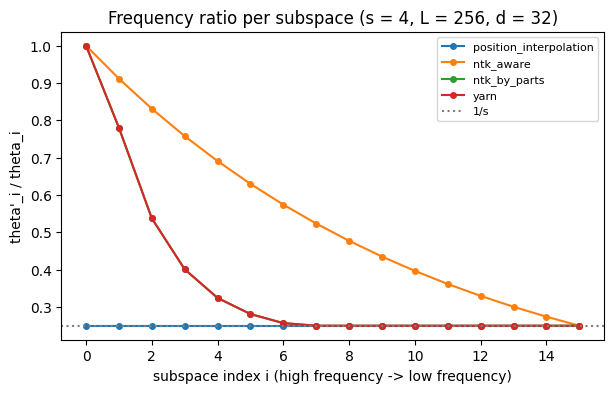

In [6]:
def make_frequency_scaling(method: str, scale: float):
    # 手法の名前と倍率 s から周波数の変換を作る("none" は変換なし)。
    if method == "none":
        return None
    if method == "position_interpolation":
        return PositionInterpolation(scale)
    if method == "ntk_aware":
        return NTKAwareScaling(scale)
    if method == "ntk_by_parts":
        return NTKByPartsScaling(scale, L, YARN_ALPHA, YARN_BETA)
    if method == "yarn":
        return YaRNScaling(scale, L, YARN_ALPHA, YARN_BETA)
    if method == "dynamic_yarn":
        return DynamicScaling(lambda s: YaRNScaling(s, L, YARN_ALPHA, YARN_BETA), L)
    raise ValueError(method)


def make_rotary(method: str, scale: float, base: float = ROPE_BASE) -> RotaryPositionEmbedding:
    return RotaryPositionEmbedding(
        HEAD_DIM, base=base, max_position=L, frequency_scaling=make_frequency_scaling(method, scale)
    ).to(device)


# --- 閉形式(FP64、NumPy) ---
_index = np.arange(0, HEAD_DIM, 2) / HEAD_DIM  # 2i / d
THETA = ROPE_BASE**-_index
WAVELENGTH = 2 * np.pi / THETA
RATIO = L / WAVELENGTH  # r_i
RAMP = np.clip((RATIO - YARN_ALPHA) / (YARN_BETA - YARN_ALPHA), 0.0, 1.0)  # gamma(r_i)


def closed_form_frequencies(method: str, s: float) -> tuple[np.ndarray, float]:
    if method == "position_interpolation":
        return THETA / s, 1.0
    if method == "ntk_aware":
        return (ROPE_BASE * s ** (HEAD_DIM / (HEAD_DIM - 2))) ** -_index, 1.0
    if method == "ntk_by_parts":
        return (1 - RAMP) * THETA / s + RAMP * THETA, 1.0
    if method == "yarn":
        return (1 - RAMP) * THETA / s + RAMP * THETA, 0.1 * math.log(s) + 1
    raise ValueError(method)


FREQUENCY_RTOL = 2e-6
for _s in EVAL_LENGTH_FACTORS:
    for _method in EVAL_METHODS[1:]:
        _freq, _factor = make_rotary(_method, _s).rotation_frequencies(_s * L)
        _expected, _expected_factor = closed_form_frequencies(_method, _s)
        _freq = _freq.cpu().double().numpy()
        assert np.allclose(_freq, _expected, rtol=FREQUENCY_RTOL, atol=0.0), (_method, _s)
        assert math.isclose(_factor, _expected_factor, rel_tol=1e-12), (_method, _s)
    _ntk, _ = make_rotary("ntk_aware", _s).rotation_frequencies(_s * L)
    assert math.isclose(float(_ntk[0]), 1.0, rel_tol=1e-7)  # 最高周波は変わらない
    assert math.isclose(float(_ntk[-1]), THETA[-1] / _s, rel_tol=FREQUENCY_RTOL)  # 最低周波は 1/s
    _parts, _ = make_rotary("ntk_by_parts", _s).rotation_frequencies(_s * L)
    _parts = _parts.cpu().double().numpy()
    assert np.allclose(
        _parts[RATIO < YARN_ALPHA], THETA[RATIO < YARN_ALPHA] / _s, rtol=FREQUENCY_RTOL
    )
    assert np.allclose(_parts[RATIO > YARN_BETA], THETA[RATIO > YARN_BETA], rtol=FREQUENCY_RTOL)
print(
    f"4 手法 x s = {EVAL_LENGTH_FACTORS} の角周波数と倍率が閉形式と一致(相対誤差 {FREQUENCY_RTOL} 以内): OK"
)

# --- 位置補間 = 位置を m/s にすること ---
_positions = torch.arange(3 * L, device=device)
_rope_interp = make_rotary("position_interpolation", 4)
_cos, _sin = _rope_interp._scaled_cos_sin(_positions, 3 * L)
_angles = np.outer(np.arange(3 * L) / 4, THETA)
assert np.allclose(_cos[:, : HEAD_DIM // 2].cpu().double().numpy(), np.cos(_angles), atol=2e-5)
assert np.allclose(_sin[:, : HEAD_DIM // 2].cpu().double().numpy(), np.sin(_angles), atol=2e-5)
print("位置補間の cos・sin が、位置 m/s のスケーリングなしの cos・sin と一致: OK")

# --- dynamic scaling: l <= L でスケーリングなしと完全に一致 ---
_rope_none = make_rotary("none", 1.0)
_rope_dynamic = make_rotary("dynamic_yarn", 1.0)
_generator = torch.Generator().manual_seed(0)
for _length in (1, L // 2, L - 1, L):
    _freq, _factor = _rope_dynamic.rotation_frequencies(_length)
    assert torch.equal(_freq, _rope_none.inv_freq) and _factor == 1.0
    _q = torch.randn(2, NUM_HEADS, _length, HEAD_DIM, generator=_generator).to(device)
    _k = torch.randn(2, NUM_HEADS, _length, HEAD_DIM, generator=_generator).to(device)
    _a, _b = _rope_dynamic.apply(_q, _k), _rope_none.apply(_q, _k)
    assert torch.equal(_a[0], _b[0]) and torch.equal(_a[1], _b[1]), _length
_freq_dynamic, _factor_dynamic = _rope_dynamic.rotation_frequencies(3 * L)
_freq_static, _factor_static = make_rotary("yarn", 3).rotation_frequencies(3 * L)
assert torch.equal(_freq_dynamic, _freq_static) and _factor_dynamic == _factor_static
print(
    "dynamic YaRN: l <= L でスケーリングなしと完全一致(torch.equal)、l = 3L で静的な YaRN(s=3)と完全一致: OK"
)

# --- YaRN = NTK-by-parts の出力の sqrt(1/t) 倍 ---
_q = torch.randn(1, NUM_HEADS, 4 * L, HEAD_DIM, generator=_generator).to(device)
_k = torch.randn(1, NUM_HEADS, 4 * L, HEAD_DIM, generator=_generator).to(device)
_qy, _ky = make_rotary("yarn", 4).apply(_q, _k)
_qp, _kp = make_rotary("ntk_by_parts", 4).apply(_q, _k)
_f = compute_yarn_attention_factor(4)
assert torch.allclose(_qy, _f * _qp, rtol=1e-6, atol=1e-6) and torch.allclose(
    _ky, _f * _kp, rtol=1e-6, atol=1e-6
)
print(
    f"YaRN の出力 = NTK-by-parts の出力 x sqrt(1/t) = {_f:.4f}(logits は 1/t = {_f**2:.4f} 倍): OK"
)

# --- 相対位置のみへの依存(両方の位置を同じだけずらしても内積が変わらない) ---
for _method in EVAL_METHODS:
    _rope = make_rotary(_method, 4)
    _q1 = torch.randn(1, 1, 1, HEAD_DIM, generator=_generator).to(device)
    _k1 = torch.randn(1, 1, 1, HEAD_DIM, generator=_generator).to(device)
    _scores = []
    for _shift in (0, 300, 700):
        _qa, _ = _rope.apply(_q1, _q1, torch.tensor([_shift + 500], device=device))
        _, _ka = _rope.apply(_k1, _k1, torch.tensor([_shift + 20], device=device))
        _scores.append(float((_qa * _ka).sum()))
    assert np.allclose(_scores, _scores[0], rtol=1e-4, atol=1e-4), (_method, _scores)
print("全手法で Query・Key の内積が相対位置のみに依存: OK")

# --- 部分空間ごとの表(s = 4) ---
print(f"\n部分空間ごとの周波数(L = {L}, d = {HEAD_DIM}, b = {ROPE_BASE}, s = {MAIN_FACTOR})")
print(
    f"{'i':>3} | {'theta_i':>10} | {'lambda_i':>10} | {'r_i':>8} | {'gamma':>6} | "
    + " | ".join(f"{m[:14]:>14}" for m in EVAL_METHODS[1:])
)
_ratios_s4 = {m: closed_form_frequencies(m, MAIN_FACTOR)[0] / THETA for m in EVAL_METHODS[1:]}
for _i in range(HEAD_DIM // 2):
    print(
        f"{_i:>3} | {THETA[_i]:>10.3e} | {WAVELENGTH[_i]:>10.1f} | {RATIO[_i]:>8.3f} | {RAMP[_i]:>6.3f} | "
        + " | ".join(f"{_ratios_s4[m][_i]:>14.4f}" for m in EVAL_METHODS[1:])
    )
print(
    f"lambda_i < L の部分空間: {int((WAVELENGTH < L).sum())} 個、r_i > beta(外挿): {int((RATIO > YARN_BETA).sum())} 個、"
    f"alpha <= r_i <= beta(混合): {int(((RATIO >= YARN_ALPHA) & (RATIO <= YARN_BETA)).sum())} 個、"
    f"r_i < alpha(補間): {int((RATIO < YARN_ALPHA).sum())} 個"
)

fig, ax = plt.subplots(figsize=(7, 4))
for _method in EVAL_METHODS[1:]:
    ax.plot(range(HEAD_DIM // 2), _ratios_s4[_method], "o-", label=_method, markersize=4)
ax.axhline(1 / MAIN_FACTOR, color="gray", linestyle=":", label="1/s")
ax.set_xlabel("subspace index i (high frequency -> low frequency)")
ax.set_ylabel("theta'_i / theta_i")
ax.set_title(f"Frequency ratio per subspace (s = {MAIN_FACTOR}, L = {L}, d = {HEAD_DIM})")
ax.legend(fontsize=8)
plt.show()

### 5.6 評価データ: 検証の部分と記事の境界

008 と同じく、Hub のコーパスのアーティファクト(`kojikojiprg/ai-theories-corpus-en-pretraining`、356 記事)を文字列の段階で
分割し、末尾の 5% を検証の部分とする(訓練に使った部分は評価に使わない)。

**記事の境界**: アーティファクトの`corpus.txt`は記事を改行 1 つで連結したもので、記事の中にも改行があるため、
`corpus.txt`だけからは境界を復元できない(下のセルで、記事の中の改行の数を印字して確かめる)。境界は
`locate_wikipedia_article_spans()`で次のいずれかから得て、どちらを使ったかを印字する。

- **Hub の`metadata.json`の`article_offsets`**(あれば優先する): `scripts/promote_canonical_corpora.py`が、マニフェストの
  全記事を個別に取得して改行 1 つで連結した結果が`corpus.txt`と文字単位で完全に一致することを確かめてから書き込んだ、
  記事ごとの文字位置。記事数がマニフェストと一致し、オフセットが単調増加で重ならず、区切りが改行 1 つであることを
  読み込み時に確かめる。Colab での実行は Wikipedia API に依存しない。
- **Wikipedia API**(`article_offsets`がない場合): マニフェストの末尾の記事から 1 つずつ取得し、**その記事がコーパスの
  対応する位置の文字列と完全に一致すること** を確かめながら、検証の部分の先頭に達するまで遡る。

2 つの方法で評価窓の集合(ハッシュ)が完全に一致することを確かめる。ローカルでは、`article_offsets`がまだ Hub にない
間はスクリプトの dry-run が書き出した`metadata.json`と、Hub にある場合は Wikipedia API と照合する。Colab では、
API への依存をなくすため、この照合を省略する。

**評価窓**: 検証の部分を記事ごとの区間(先頭の区間は記事の途中から始まる)に分け、区間ごとに別々に符号化する。各区間の
先頭から、長さ $8L$(最大の評価長)の重ならない窓を切り出し、端数は捨てる。**したがってどの窓も 1 つの記事の中に収まる。**
本番ではすべての窓を使う。スモークテストでは、評価窓を 2 個以上持つ記事を先頭から 3 本選び、それぞれ先頭の 2 個の窓を使う
(記事を単位とするブートストラップの経路を、同じ記事に複数の窓があるクラスタを含めて実行するため。2 本以上の記事から選ばれ、
2 個以上の窓を持つ記事を含むことをアサーションで確かめる)。
評価長 $2L, 4L$ では、同じ窓の先頭の $2L, 4L$ トークンを使う(全水準で同じテキストの対応がとれる)。長さ $L$ の評価
(実験 D)では、各窓を 8 個の長さ $L$ の区間に分けて、それぞれ独立に評価する。

**bits-per-byte の分母**: 予測対象のトークンに対応する UTF-8 バイト数。トークナイザはバイトレベル BPE なので、各トークンの
バイト数は語彙の記号の長さで決まる。区間のトークンのバイト数の合計が区間の UTF-8 バイト数に等しく、復号が区間の文字列に
一致すること(可逆性)をアサーションで確かめる。位置 $j$ のトークン(窓の中の 0 始まりの番号)は、位置 $j-1$ の Query が
位置 $0, \dots, j-1$ の Key を見て予測する。位置 0 のトークンは予測しない。「位置の範囲 $[a, c)$」は、予測対象の
トークンの位置 $j$ の範囲を指す($[0, L)$ は $j = 1, \dots, L-1$)。

In [7]:
_t0 = time.time()
corpus_text, corpus_metadata = load_wikipedia_corpus_with_fallback(
    "en", CORPUS_REPO_ID, WIKIPEDIA_CACHE_DIR, manifest_path=MANIFEST_PATH, return_metadata=True
)
assert len(corpus_text.encode("utf-8")) == corpus_metadata["raw_bytes"], (
    "コーパスの取得が破損している"
)
assert corpus_metadata["validation_ratio"] in (None, VALIDATION_RATIO)
train_text, validation_text = split_train_val_text(corpus_text, VALIDATION_RATIO)
VALIDATION_START = len(train_text)
print(
    f"コーパス: {len(corpus_text):,} 文字(取得元 {corpus_metadata['source']}、{time.time() - _t0:.1f}s)、"
    f"検証の部分: {len(validation_text):,} 文字(文字位置 {VALIDATION_START:,} から)"
)

# --- 記事の境界(Hub の metadata.json の article_offsets、なければ Wikipedia API) ---
_t0 = time.time()
article_spans, ARTICLE_SPANS_SOURCE = locate_wikipedia_article_spans(
    corpus_text,
    "en",
    WIKIPEDIA_CACHE_DIR,
    MANIFEST_PATH,
    repo_id=CORPUS_REPO_ID,
    start_position=VALIDATION_START,
)
ARTICLE_FETCH_SECONDS = time.time() - _t0
_source_label = {
    "metadata": "Hub の metadata.json の article_offsets",
    "wikipedia_api": "Wikipedia API から取得してコーパスと照合",
}[ARTICLE_SPANS_SOURCE]
print(f"記事の境界の取得元: {ARTICLE_SPANS_SOURCE}({_source_label}、{ARTICLE_FETCH_SECONDS:.1f}s)")
print(
    f"検証の部分にかかる記事: {len(article_spans)} 件(マニフェストの番号 "
    f"{article_spans[0]['manifest_index']}〜{article_spans[-1]['manifest_index']})"
)
_newlines_inside = sum(corpus_text.count("\n", sp["start"], sp["end"]) for sp in article_spans)
print(
    f"これらの記事の中の改行の数: {_newlines_inside:,}(記事の区切りと同じ改行 1 つが記事の中にもあるため、"
    "corpus.txt だけからは境界を復元できない)"
)

TOKEN_BYTE_LENGTHS = np.array(
    [len(tokenizer.id_to_symbol[i]) for i in range(VOCAB_SIZE)], dtype=np.int64
)  # バイトレベル BPE: 記号 1 文字 = 1 バイト
_window_length = MAX_FACTOR * L


def build_evaluation_windows(spans: list[dict]) -> dict:
    # 検証の部分を記事ごとの区間に分け(先頭の区間は記事の途中から)、区間ごとに符号化して長さ 8L の窓を切り出す。
    segments = [
        (sp["manifest_index"], corpus_text[max(sp["start"], VALIDATION_START) : sp["end"]])
        for sp in spans
    ]
    assert "\n".join(t for _, t in segments) == validation_text, (
        "区間を連結しても検証の部分にならない"
    )
    windows, info, rows, segment_ids = [], [], [], []
    for segment_number, (idx, text) in enumerate(segments):
        ids = tokenizer.encode(text)
        segment_ids.append(ids)
        assert tokenizer.decode(ids) == text, "符号化が可逆でない"
        assert int(TOKEN_BYTE_LENGTHS[ids].sum()) == len(text.encode("utf-8")), (
            "バイト数の合計が合わない"
        )
        count = len(ids) // _window_length
        for w in range(count):
            offset = w * _window_length
            windows.append(ids[offset : offset + _window_length])
            info.append(
                {
                    "segment": segment_number,
                    "manifest_index": idx,
                    "token_offset": offset,
                    "segment_tokens": len(ids),
                }
            )
        rows.append((idx, len(text), len(ids), count))
    tensor = torch.tensor(windows, dtype=torch.long)
    digest = hashlib.sha256(tensor.numpy().tobytes())
    digest.update(json.dumps(info).encode("utf-8"))
    return {
        "windows": tensor,
        "info": info,
        "rows": rows,
        "segment_ids": segment_ids,
        "hash": digest.hexdigest(),
    }


_evaluation_data = build_evaluation_windows(article_spans)
EVAL_WINDOWS_ALL = _evaluation_data["windows"]
WINDOW_INFO_ALL = _evaluation_data["info"]
_segment_ids = _evaluation_data["segment_ids"]
_segment_rows = _evaluation_data["rows"]
print(f"\n{'番号':>4} | {'文字数':>9} | {'トークン数':>10} | {'8L の窓':>7}")
for _row in _segment_rows:
    print(f"{_row[0]:>4} | {_row[1]:>9,} | {_row[2]:>10,} | {_row[3]:>7}")
_n_tokens = sum(r[2] for r in _segment_rows)
print(
    f"8L = {_window_length} トークン以上の記事の区間: {sum(r[2] >= _window_length for r in _segment_rows)} / "
    f"{len(_segment_rows)} 件、作れる評価窓: {len(EVAL_WINDOWS_ALL)} 個"
    f"(検証の部分の {_n_tokens:,} トークンのうち {len(EVAL_WINDOWS_ALL) * _window_length:,} トークンを使う)、"
    f"評価窓を持つ記事: {len({i['manifest_index'] for i in WINDOW_INFO_ALL})} 本、"
    f"全評価窓のハッシュ {_evaluation_data['hash'][:16]}"
)

# --- 2 つの方法(article_offsets と Wikipedia API)で評価窓の集合が一致すること ---
_alternative = None
if ARTICLE_SPANS_SOURCE == "wikipedia_api" and ARTICLE_OFFSETS_DRY_RUN_PATH.exists():
    _alternative = locate_wikipedia_article_spans(
        corpus_text,
        "en",
        WIKIPEDIA_CACHE_DIR,
        MANIFEST_PATH,
        metadata_path=ARTICLE_OFFSETS_DRY_RUN_PATH,
        start_position=VALIDATION_START,
    )
elif ARTICLE_SPANS_SOURCE == "metadata" and not IN_COLAB:
    _alternative = locate_wikipedia_article_spans(
        corpus_text, "en", WIKIPEDIA_CACHE_DIR, MANIFEST_PATH, start_position=VALIDATION_START
    )
if _alternative is not None:
    _alternative_spans, _alternative_source = _alternative
    assert _alternative_source != ARTICLE_SPANS_SOURCE
    assert _alternative_spans == article_spans, "2 つの方法で記事の範囲が一致しない"
    _alternative_hash = build_evaluation_windows(_alternative_spans)["hash"]
    assert _alternative_hash == _evaluation_data["hash"], "2 つの方法で評価窓の集合が一致しない"
    print(
        f"記事の範囲と評価窓の集合(ハッシュ {_alternative_hash[:16]})が、{ARTICLE_SPANS_SOURCE} と "
        f"{_alternative_source} で完全に一致: OK"
    )
else:
    print(
        "記事の境界の 2 つの方法による照合は省略した"
        "(Colab では Wikipedia API に依存しないため、またはローカルに dry-run の結果がないため)"
    )


def select_windows(info: list[dict], max_windows: int | None, per_article: int = 2) -> list[int]:
    # None ならすべて。そうでなければ、評価窓を per_article 個以上持つ記事を先頭から max_windows // per_article 本選び、
    # それぞれ先頭の per_article 個の窓を使う(同じ記事に複数の窓があるクラスタを含め、2 本以上の記事から選ぶ)。
    if max_windows is None:
        return list(range(len(info)))
    by_article: dict[int, list[int]] = {}
    for i, entry in enumerate(info):
        by_article.setdefault(entry["manifest_index"], []).append(i)
    eligible = [indices for indices in by_article.values() if len(indices) >= per_article]
    chosen = [
        i for indices in eligible[: max_windows // per_article] for i in indices[:per_article]
    ]
    return sorted(chosen)


# 本番(またはスモークテスト)で使う評価窓
_selected = select_windows(WINDOW_INFO_ALL, MAX_EVAL_WINDOWS)
EVAL_WINDOWS = EVAL_WINDOWS_ALL[_selected]
WINDOW_INFO = [WINDOW_INFO_ALL[i] for i in _selected]
WINDOW_ARTICLES = [
    i["manifest_index"] for i in WINDOW_INFO
]  # 記事を単位とするブートストラップのクラスタ
NUM_EVAL_ARTICLES = len(set(WINDOW_ARTICLES))
assert NUM_EVAL_ARTICLES >= 2, (
    "評価窓が 2 本以上の記事から選ばれていない(クラスタブートストラップの経路を通らない)"
)
# 同じ記事に複数の窓があるクラスタを含む(クラスタが窓と一致せず、記事を単位とする経路が窓を単位とする経路と区別される)
assert max(WINDOW_ARTICLES.count(a) for a in set(WINDOW_ARTICLES)) >= 2
NUM_EVAL_WINDOWS = len(EVAL_WINDOWS)
TARGET_BYTES = TOKEN_BYTE_LENGTHS[
    EVAL_WINDOWS[:, 1:].numpy()
]  # (窓, 8L - 1): 列 c は位置 j = c + 1
EVAL_WINDOWS_HASH = hashlib.sha256(EVAL_WINDOWS.numpy().tobytes()).hexdigest()[:16]

# 不変条件: どの窓も 1 つの記事の区間の中に収まり、その区間のトークン列の連続した部分列である(前提条件 P-C1 の根拠)
for _w, _info in zip(EVAL_WINDOWS, WINDOW_INFO, strict=True):
    _ids = _segment_ids[_info["segment"]]
    assert _info["token_offset"] + _window_length <= len(_ids) == _info["segment_tokens"]
    assert _w.tolist() == _ids[_info["token_offset"] : _info["token_offset"] + _window_length]
WINDOWS_WITHIN_ARTICLE = all(
    _info["token_offset"] + _window_length <= _info["segment_tokens"] for _info in WINDOW_INFO
)
# P0 の評価集合: モデルカードと同じ(検証の部分全体を長さ L の重ならない窓に区切る、記事の境界によらない)
P0_WINDOWS, P0_MASK = make_evaluation_windows(
    torch.tensor(tokenizer.encode(validation_text), dtype=torch.long), L
)
print(
    f"使う評価窓: {NUM_EVAL_WINDOWS} 個・{NUM_EVAL_ARTICLES} 本の記事(水準 {CURRENT_LEVEL_NAME!r})、"
    f"記事ごとの窓の数 {dict(sorted({a: WINDOW_ARTICLES.count(a) for a in set(WINDOW_ARTICLES)}.items()))}、"
    f"ハッシュ {EVAL_WINDOWS_HASH}、"
    f"すべて 1 つの記事の中: {WINDOWS_WITHIN_ARTICLE}"
)

corpus.txt: reconstructing file:   0%|          |  0.00B / 24.3MB            

corpus.txt: downloading bytes:           |  0.00B            

metadata.json:   0%|          | 0.00/43.4k [00:00<?, ?B/s]

コーパス取得元: kojikojiprg/ai-theories-corpus-en-pretraining(Hugging Face Hub)
コーパス: 24,214,546 文字(取得元 hub、1.9s)、検証の部分: 1,210,727 文字(文字位置 23,003,819 から)
記事の境界の取得元: metadata(Hub の metadata.json の article_offsets、0.1s)
検証の部分にかかる記事: 18 件(マニフェストの番号 338〜355)
これらの記事の中の改行の数: 9,333(記事の区切りと同じ改行 1 つが記事の中にもあるため、corpus.txt だけからは境界を復元できない)

  番号 |       文字数 |      トークン数 |   8L の窓
 338 |    53,678 |     13,305 |       6
 339 |    50,953 |     15,005 |       7
 340 |   165,445 |     38,455 |      18
 341 |    49,875 |     12,262 |       5
 342 |   122,195 |     32,780 |      16
 343 |    95,544 |     23,796 |      11
 344 |     2,416 |        701 |       0
 345 |       912 |        211 |       0
 346 |    14,666 |      4,847 |       2
 347 |    76,711 |     17,001 |       8
 348 |     1,070 |        331 |       0
 349 |    87,147 |     23,417 |      11
 350 |     1,828 |        503 |       0
 351 |   138,584 |     34,257 |      16
 352 |     7,974 |      1,942 |       0
 353 |    29,513 |      8,756 |     

### 5.7 微調整・較正のデータ

微調整(実験 B)は 008 の訓練の部分(コーパスの先頭 95%)で行う。その末尾の`CALIBRATION_CHARS`文字を較正用に取り分け、
微調整には使わない。**較正用のテキストは 008 の事前学習で使った部分であり、未見のテキストではない**(6.1 節)。
較正用の窓は長さ $4L$ の重ならない窓で、記事の境界はまたぎうる(学習率の選択と、前提条件の損失の測定にのみ使う)。

微調整の部分は`encode_text_to_memmap()`で`.cache/015_encoded/`に`uint16`の memmap として符号化する(同一セッション内の
再実行では再符号化しない)。キャッシュから読んだトークン列が、キャッシュを経由せず直接符号化したトークン列と一致すること
(単語の境界で切った先頭の部分で比べる)と、本番のステップ数が 1 エポックを超えないことを確かめる。

In [8]:
finetune_text = train_text[:-CALIBRATION_CHARS]
calibration_text = train_text[-CALIBRATION_CHARS:]
_t0 = time.time()
finetune_ids = encode_text_to_memmap(tokenizer, finetune_text, ENCODED_CACHE_DIR / "finetune.u16")
FINETUNE_ENCODE_SECONDS = time.time() - _t0
# キャッシュを経由しない符号化との一致(単語の境界で切った先頭の部分)
_cut = re.compile(r"\S\s").search(finetune_text, 300_000).start() + 1
_direct = tokenizer.encode(finetune_text[:_cut])
assert np.array_equal(
    np.asarray(finetune_ids[: len(_direct)], dtype=np.int64), np.array(_direct)
), "キャッシュのトークン列が直接の符号化と一致しない"
print(
    f"微調整の部分: {len(finetune_text):,} 文字 -> {len(finetune_ids):,} トークン"
    f"({FINETUNE_ENCODE_SECONDS:.1f}s)、先頭 {len(_direct):,} トークンが直接の符号化と一致: OK"
)

_calibration_ids = torch.tensor(tokenizer.encode(calibration_text), dtype=torch.long)
_calibration_all, _ = make_evaluation_windows(_calibration_ids, FINETUNE_FACTOR * L)
_calibration_all = _calibration_all[
    : len(_calibration_ids) // (FINETUNE_FACTOR * L)
]  # 端数の窓は捨てる
assert len(_calibration_all) >= LEVELS["prod"]["CALIBRATION_WINDOWS"], "較正用の窓が足りない"
calibration_windows = _calibration_all[:CALIBRATION_WINDOWS]
calibration_mask = torch.ones_like(calibration_windows, dtype=torch.bool)
CALIBRATION_TARGET_BYTES = TOKEN_BYTE_LENGTHS[calibration_windows[:, 1:].numpy()]
print(
    f"較正用: {len(calibration_text):,} 文字 -> 長さ {FINETUNE_FACTOR * L} の窓 {len(_calibration_all)} 個のうち "
    f"{len(calibration_windows)} 個を使う"
)

TOKENS_PER_STEP = FINETUNE_BATCH_SIZE * FINETUNE_FACTOR * L
for _level in LEVELS.values():
    assert _level["FINETUNE_STEPS"] * TOKENS_PER_STEP <= len(finetune_ids), "1 エポックを超える"
print(
    f"微調整: 1 ステップ {TOKENS_PER_STEP:,} トークン、本番 {LEVELS['prod']['FINETUNE_STEPS']} ステップで "
    f"{LEVELS['prod']['FINETUNE_STEPS'] * TOKENS_PER_STEP / len(finetune_ids):.2f} エポック"
    f"(008 の事前学習 2,181 ステップ x 8,192 トークンの "
    f"{LEVELS['prod']['FINETUNE_STEPS'] * TOKENS_PER_STEP / (2181 * 8192):.1%})"
)

.cache/015_encoded/finetune.u16: 5,914,639 トークンを uint16 memmap として書き出した
微調整の部分: 22,843,819 文字 -> 5,914,639 トークン(17.1s)、先頭 73,390 トークンが直接の符号化と一致: OK
較正用: 160,000 文字 -> 長さ 1024 の窓 40 個のうち 32 個を使う
微調整: 1 ステップ 8,192 トークン、本番 400 ステップで 0.55 エポック(008 の事前学習 2,181 ステップ x 8,192 トークンの 18.3%)


### 5.8 評価のハーネス

- `set_rotary(model, method, s, base)`: モデルの全層の RoPE を、指定した手法・倍率の`RotaryPositionEmbedding`に差し替える
  (全層で 1 つのインスタンスを共有する。008 と同じ)。
- `token_losses(model, windows)`: 窓ごと・位置ごとの損失(nats)。列 $c$ は位置 $j = c + 1$ のトークンの損失。
- `range_bits(losses, a, c)`・`range_bytes(bytes, a, c)`: 位置の範囲 $[a, c)$ の、窓ごとの損失の合計(ビット)と分母(バイト)。
  bits-per-byte は窓をまたいで合計してから割る(比の平均ではなく、合計の比)。
- `truncated_token_losses(model, windows, a, c, context)`: 位置 $j \in [a, c)$ の各トークンを、直前の`context`トークン
  $x_{j-\mathrm{context}}, \dots, x_{j-1}$ **だけ** を入力として予測したときの損失(実験 C)。系列ごとに独立に順伝播するので、
  層を重ねても $j - \mathrm{context}$ より前のトークンの情報は入らない(スライディングウィンドウのマスクでは層ごとに受容野が
  広がるので使わない)。出力層は最後の位置にだけ適用する(`last_position_logits()`。モデルの順伝播と同じ計算で、
  最後の位置の logits が一致することを確かめる)。
- 同じ(モデル・手法・倍率・長さ)の損失は 1 回だけ計算し、`LOSS_CACHE`から再利用する(実験 A・C・D で共有する)。
  再利用した値が、計算し直した値と完全に一致することを 6.9 節で確かめる。

In [9]:
def set_rotary(model: GPTLanguageModel, method: str, scale: float, base: float = ROPE_BASE):
    rope = make_rotary(method, scale, base)
    for block in model.blocks:
        block.self_attn.positional_transform = rope
    model.max_sequence_length = MAX_FACTOR * L
    return rope


def token_losses(
    model: GPTLanguageModel, windows: torch.Tensor, batch_size: int = EVAL_BATCH_SIZE
) -> np.ndarray:
    # 窓ごと・位置ごとの損失(nats)。形状 (窓, 長さ - 1)。
    model.eval()
    rows = []
    with torch.no_grad():
        for start in range(0, len(windows), batch_size):
            batch = windows[start : start + batch_size].to(device)
            logits = model(batch)[:, :-1]
            losses = F.cross_entropy(
                logits.reshape(-1, VOCAB_SIZE), batch[:, 1:].reshape(-1), reduction="none"
            ).view(batch.size(0), -1)
            rows.append(losses.float().cpu().numpy().astype(np.float64))
    return np.concatenate(rows)


def range_bits(losses: np.ndarray, start: int, end: int) -> np.ndarray:
    # 位置 j in [start, end) の損失の窓ごとの合計(ビット)。列 c は位置 j = c + 1。
    return losses[:, max(start, 1) - 1 : end - 1].sum(axis=1) / LOG2


def range_bytes(target_bytes: np.ndarray, start: int, end: int) -> np.ndarray:
    return target_bytes[:, max(start, 1) - 1 : end - 1].sum(axis=1).astype(np.float64)


def bits_per_byte(bits: np.ndarray, byte_counts: np.ndarray) -> float:
    return float(np.sum(bits) / np.sum(byte_counts))


def last_position_logits(model: GPTLanguageModel, tokens: torch.Tensor) -> torch.Tensor:
    # GPTLanguageModel.forward と同じ計算を行い、出力層だけを最後の位置に限る(実験 C の高速化)。
    hidden = model.token_embedding(tokens)
    mask = create_causal_mask(tokens.size(1), device=tokens.device)
    for block in model.blocks:
        hidden, _, _ = block(hidden, None, tgt_mask=mask)
    return model.lm_head(model.final_norm(hidden[:, -1]))


def truncated_token_losses(
    model: GPTLanguageModel, windows: torch.Tensor, start: int, end: int, context: int
) -> np.ndarray:
    # 位置 j in [start, end) のトークンを、直前の context トークンだけから予測したときの損失。形状 (窓, end - start)。
    assert start >= context
    sequences = windows[:, start - context : end].unfold(
        1, context + 1, 1
    )  # (窓, end - start, context + 1)
    flat = sequences.reshape(-1, context + 1)
    model.eval()
    rows = []
    with torch.no_grad():
        for s in range(0, len(flat), TRUNCATED_BATCH_SIZE):
            batch = flat[s : s + TRUNCATED_BATCH_SIZE].to(device)
            logits = last_position_logits(model, batch[:, :context])
            rows.append(
                F.cross_entropy(logits, batch[:, context], reduction="none").float().cpu().numpy()
            )
    return np.concatenate(rows).astype(np.float64).reshape(len(windows), end - start)


LOSS_CACHE: dict[tuple, np.ndarray] = {}


def cached_losses(key: tuple, compute) -> np.ndarray:
    if key not in LOSS_CACHE:
        LOSS_CACHE[key] = compute()
    return LOSS_CACHE[key]


def base_losses(method: str, factor: int) -> np.ndarray:
    # 微調整なしのモデルの、評価窓の先頭 factor x L トークンでの損失(s = factor)。
    def compute():
        set_rotary(base_model, method, factor)
        return token_losses(base_model, EVAL_WINDOWS[:, : factor * L])

    return cached_losses(("base", method, factor), compute)


# 最後の位置だけの logits が、モデルの順伝播の最後の位置の logits と一致すること
set_rotary(base_model, "yarn", FINETUNE_FACTOR)
with torch.no_grad():
    _probe_tokens = EVAL_WINDOWS[:2, :L].to(device)
    assert torch.allclose(
        last_position_logits(base_model, _probe_tokens), base_model(_probe_tokens)[:, -1], atol=1e-4
    )
# 切り詰めた評価の整合性: 位置 j = L のトークンは、全文脈でも直前の L トークンが文脈のすべてなので、両者が一致する
set_rotary(base_model, "none", 1)
_full = token_losses(base_model, EVAL_WINDOWS[:2, : L + 1])[:, L - 1]
_truncated = truncated_token_losses(base_model, EVAL_WINDOWS[:2], L, L + 1, L)[:, 0]
assert np.allclose(_full, _truncated, atol=1e-4), (_full, _truncated)
# 範囲の関数: [0, 8L) の分母は窓のバイト数から先頭トークンを除いたもの
assert np.array_equal(
    range_bytes(TARGET_BYTES, 0, MAX_FACTOR * L),
    TOKEN_BYTE_LENGTHS[EVAL_WINDOWS.numpy()].sum(axis=1)
    - TOKEN_BYTE_LENGTHS[EVAL_WINDOWS[:, 0].numpy()],
)
print(
    "評価のハーネス: 最後の位置だけの logits がモデルの順伝播と一致、"
    "切り詰めた評価(文脈 L)と全文脈の評価が位置 j = L で一致: OK"
)

評価のハーネス: 最後の位置だけの logits がモデルの順伝播と一致、切り詰めた評価(文脈 L)と全文脈の評価が位置 j = L で一致: OK


### 5.9 微調整のハーネス

1 回の微調整(1 手法 × 1 シード × 1 学習率)を実行し、判定と診断に必要な量を記録して返す。モデルそのものは返さず、
保存もしない。

- ベースモデルを複製し、手法の RoPE に差し替える(位置補間・YaRN は $s = 4$ の静的なスケーリング、底の調整は底を
  $b' = b s^{d/(d-2)}$ にした変換なしの RoPE)。**全パラメータを学習する。**
- 学習は`train_language_model()`で、AdamW・warmup(ステップ数の 10%)+ cosine(最小学習率はピークの 1%)・
  gradient clipping・FP32、系列長 $4L$・バッチサイズ 8。シードは訓練のバッチの選び方を決め、**同じシードなら手法によらず
  同じバッチの列になる**(手法間で対応がとれる)。
- 学習の前後で、較正用の窓(長さ $4L$、全位置)の平均損失を同じ関数で測る(前提条件 P-B1)。
- `evaluate=True`のとき、評価窓の先頭 $4L$ トークンの位置ごとの損失を記録する。実験 C の切り詰めた評価
  (位置 $[3L, 4L)$ を直前の $L$ トークンから予測)も、YaRN では全シード、位置補間では診断用のシードで行う。

In [10]:
def build_finetune_model(method: str) -> GPTLanguageModel:
    model = copy.deepcopy(base_model)
    if method == "adjusted_base":
        set_rotary(model, "none", 1, base=ADJUSTED_BASE)
    else:
        set_rotary(model, method, FINETUNE_FACTOR)
    return model


def mean_loss_nats(model: GPTLanguageModel, windows: torch.Tensor) -> float:
    return float(token_losses(model, windows).mean())


def run_finetune(
    method: str,
    seed: int,
    learning_rate: float,
    clip_threshold: float | None,
    num_steps: int,
    evaluate: bool = True,
) -> dict:
    model = build_finetune_model(method)
    initial_loss = mean_loss_nats(model, calibration_windows)
    optimizer = AdamW(list(model.parameters()), lr=learning_rate, weight_decay=WEIGHT_DECAY)
    schedule = functools.partial(
        compute_warmup_cosine_learning_rate,
        warmup_steps=max(1, round(WARMUP_RATIO * num_steps)),
        total_steps=num_steps,
        peak_learning_rate=learning_rate,
        min_learning_rate=learning_rate * MIN_LEARNING_RATE_RATIO,
    )
    history = train_language_model(
        model,
        finetune_ids,
        calibration_windows,
        calibration_mask,
        int(CALIBRATION_TARGET_BYTES.sum()),
        num_steps=num_steps,
        batch_size=FINETUNE_BATCH_SIZE,
        sequence_length=FINETUNE_FACTOR * L,
        learning_rate=learning_rate,
        eval_interval=num_steps,
        device=device,
        seed=seed,
        optimizer=optimizer,
        learning_rate_schedule=schedule,
        gradient_clip_threshold=clip_threshold,
        evaluate_at_final_step=True,
    )
    calibration_losses = token_losses(model, calibration_windows)
    record = {
        "method": method,
        "seed": seed,
        "learning_rate": learning_rate,
        "clip_threshold": clip_threshold,
        "num_steps": num_steps,
        "history_length": len(history["train_loss"]),
        "initial_loss": initial_loss,
        "final_loss": float(calibration_losses.mean()),
        "calibration_bits_per_byte": bits_per_byte(
            range_bits(calibration_losses, L, FINETUNE_FACTOR * L),
            range_bytes(CALIBRATION_TARGET_BYTES, L, FINETUNE_FACTOR * L),
        ),
        "train_loss": history["train_loss"],
        "gradient_norm": history["gradient_norm"],
        "clip_trigger_ratio": float(np.mean(history["gradient_clip_triggered"])),
        "all_finite": bool(np.all(np.isfinite(history["train_loss"]))),
    }
    if evaluate:
        record["eval_losses"] = token_losses(model, EVAL_WINDOWS[:, : FINETUNE_FACTOR * L])
        record["eval_windows_hash"] = EVAL_WINDOWS_HASH
        if method == "yarn" or (method == "position_interpolation" and seed in DIAGNOSTIC_SEEDS):
            record["truncated_losses"] = truncated_token_losses(
                model, EVAL_WINDOWS, (FINETUNE_FACTOR - 1) * L, FINETUNE_FACTOR * L, L
            )
    del model
    return record

## 6. 実験 / Experiments

### 6.1 実験宣言セル: 共通の設定・検証すること・判定基準・前提条件

**この節の内容は本番実行の前に確定させ、結果を見た後に変更しない。**

#### 共通の設定

- **起点**: `kojikojiprg/ai-theories-small-gpt-en`の`main`(008 で事前学習、$L = 256$、$d = 32$、$b = 10000$、4 層・8 ヘッド)。
  トークナイザは`kojikojiprg/ai-theories-tokenizer-en`。
- **評価データ**: 008 の検証の部分(コーパスの末尾 5%)から、1 つの記事の中に収まる長さ $8L$ の重ならない窓を切り出したもの
  (5.6 節)。評価長 $2L, 4L$ では同じ窓の先頭の部分を使い、長さ $L$ の評価では各窓を 8 区間に分ける。
- **指標**: bits-per-byte。分母は、評価した(予測対象の)トークンに対応する UTF-8 バイト数。全条件でトークナイザが同じなので
  1 トークンあたりの指標でも条件間の比較は成り立つが、他のトピックとの一貫性のために bits-per-byte で報告する。位置の範囲
  $[a, c)$ の bits-per-byte は、全窓の損失の合計(ビット)を全窓のバイト数の合計で割る(合計の比)。
- **ばらつきの単位**: 微調整なしのモデルは決定的なので、実験 A・D のばらつきは **どの評価テキストを選んだか** に由来する
  (同じ分布の別のテキストで評価したらどう変わるか)。これを、**記事を単位とする対応付きのクラスタブートストラップ**
  (cluster bootstrap)で求める。反復ごとに、評価窓を持つ記事(本番では 12 本)を記事の数だけ復元抽出し、選ばれた記事の
  全評価窓を(重複して選ばれた記事は重複して)使って、各条件の合計の比を計算してから差をとる
  (`paired_cluster_bootstrap_ratio_of_sums()`、反復 $R = 10{,}000$ 回)。比べる全条件・全モデルに同じ再標本を使う(対応付き)。
  対比量の標準偏差は、反復ごとの差の標本標準偏差とする。記事ごとの難しさの違いは条件間で相殺されるので、対応のない
  比較より標準偏差が小さくなる。
- **判定基準の改訂の記録(実験 A〜D の標準偏差に共通、スモークテストの後・本番実行の前に改訂した)**:
  - **旧基準**: 評価窓を単位とする対応付きブートストラップ(反復ごとに評価窓を窓の数だけ復元抽出する、
    `paired_bootstrap_ratio_of_sums()`)で、$\sigma_A$・$\sigma_D$ と、実験 B・C の $\sigma_{\mathrm{window}}$ を求める。
  - **新基準**: 上のとおり、記事を単位とするクラスタブートストラップで同じ量を求める。$\sigma_{\mathrm{seed}}$ の導出、
    $\sigma = \sqrt{\sigma_{\mathrm{seed}}^2 + \sigma_{\mathrm{window}}^2}$ の形、対比量の定義、判定基準の形(支持: $\Delta - 2\sigma > 0$、
    反証: $\Delta + 2\sigma < 0$)、判定する水準は変えない。
  - **改訂の理由**: 本番の 147 個の評価窓は 12 本の記事から切り出したもので、1 本の記事だけで 43 個を占める。同じ記事の窓は
    話題・文体・固有名詞を共有し、互いに独立ではない。独立でない単位を独立なものとして復元抽出すると、標準偏差を過小に
    見積もる(擬似反復、pseudoreplication)。独立な単位は記事なので、記事を復元抽出する(実験 D で「同じ窓の 8 区間は
    相関するので窓を単位にする」としたのと同じ理由が、同じ記事の窓どうしにも当てはまる)。**この改訂は標本の独立性という
    一般論に基づくもので、スモークテストの結果の方向には依存しない。**
  - 旧基準による標準偏差は、判定に使わない診断量として引き続き計算・印字する。あわせて、1 本の記事が対比量を支配して
    いないかを見るため、記事ごとの対比量と記事ごとの評価窓の数を診断量として印字する。
  - **スモークテストの旧基準による結果(記録)**: コミット`a6b81cf`のセル出力(ローカルの MPS、評価窓 4 個はすべて
    記事 338 から、判定に使う条件のシード 2、ステップ 8)。実験 A: $\Delta_A = +0.1378$、$\sigma_A = 0.0114$、判定関数の結果は
    支持。実験 B: $\Delta_B = +0.0982$、$\sigma_{\mathrm{seed}} = 0.0037$、$\sigma_{\mathrm{window}} = 0.0093$、$\sigma_B = 0.0100$、支持。
    実験 C: $\Delta_C = +0.0054$、$\sigma_{\mathrm{seed}} = 0.0009$、$\sigma_{\mathrm{window}} = 0.0033$、$\sigma_C = 0.0034$、判定不能。
    実験 D: $\Delta_D = +0.0396$、$\sigma_D = 0.0022$、支持。いずれも動作確認のための値であり、結論ではない(評価窓が
    1 本の記事から選ばれていたため、この時点ではクラスタブートストラップの経路を実行できなかった。改訂後のスモークテストでは、
    評価窓を 3 本の記事から 2 個ずつ選ぶ)。
- **判定の形**: 対比量を $\Delta$、その標準偏差を $\sigma$ として、支持: $\Delta - 2\sigma > 0$、反証: $\Delta + 2\sigma < 0$、
  判定不能: それ以外(差が標準偏差の 2 倍以内に収まる)。前提条件が 1 つでも成立しなかった実験は、判定関数の結果に
  関わらず **前提不成立** とし、判定不能とは区別して報告する。
- **YaRN のハイパーパラメータは原論文の値に固定する** ($\alpha = 1$、$\beta = 32$、$\sqrt{1/t} = 0.1 \ln s + 1$)。
  評価集合で調整すると、判定に使うデータで YaRN だけを有利に選ぶことになる(位置補間には調整するハイパーパラメータが
  ないので、調整は YaRN にのみ働く)。原論文の値は実務で使われている値でもある。$L$ の小さい本モデルでは同じ $\alpha, \beta$
  でも外挿される部分空間が 1 個しかない(3.5 節)ことは、実験の前に config から決まる性質として承知したうえで固定する。
- **評価では KV キャッシュを使わない**(3.7 節)。
- **共通の前提条件 P0**: 読み込んだモデル(スケーリングなし)の、**モデルカードの値と同じ評価集合**(008 の検証の部分全体を
  長さ $L$ の重ならない窓に区切ったもの。記事の境界によらない)での bits-per-byte が、モデルカードの値 1.668067 と
  $|b_{\mathrm{P0}} - 1.668067| \le 0.002$ で一致すること。
  - **評価窓の違いの扱い**: 本ノートブックの評価窓(記事の中の窓)とモデルカードの評価窓は異なり、記事の境界をまたぐ窓の
    有無や窓の中の位置の分布が違うので、両者の bits-per-byte は一致する必要がない。そこで P0 は、モデルカードと **同じ**
    評価集合・同じ関数(`evaluate_bits_per_byte()`)で計算する。評価窓の違いがなくなるので、許容誤差は計算のデバイスや
    演算の順序による浮動小数点の差だけを見込めばよい(FP32 の損失の合計で $10^{-5}$ 程度)。0.002 はそれより十分大きく、
    重みの取り違え・トークナイザの取り違え・底 $b$ の誤り(いずれも bits-per-byte を 0.1 以上変えると見込まれる)より十分
    小さい。記事の中の窓でのスケーリングなしの bits-per-byte(長さ $L$ の区間)は、診断量として並べて印字する。
  - P0 はどの手法の効果とも独立な、読み込みの正しさの条件である。全実験の前提条件とする。

#### 実験 A: 微調整なしでの外挿(高周波の保存の効果)

- **検証すること**: 推論時にだけ適用した YaRN は、位置補間より、学習長を超える位置のトークンの bits-per-byte が低い。
- **条件**: スケーリングなし・位置補間・NTK-aware・NTK-by-parts(診断用、YaRN から温度の補正を除いたもの)・YaRN。
  評価長 $2L, 4L, 8L$(公比 2 の等比)、$s$ = 評価長 $/ L$。
- **判定する水準**: $4L$($s = 4$)のみ。$2L$・$8L$ は診断量とする。
- **対比量**: 評価長 $4L$ の同じ評価窓・同じ位置の範囲 $[L, 4L)$ での、位置補間と YaRN の bits-per-byte の差
  $\Delta_A = b_{\mathrm{interp}} - b_{\mathrm{yarn}}$。$b_{\mathrm{interp}}$・$b_{\mathrm{yarn}}$ はそれぞれの手法の、全窓の
  $[L, 4L)$ の損失の合計(ビット)をバイト数の合計で割った値である。正の値は YaRN の方が低い(良い)ことを表す。
- **標準偏差**: $\sigma_A$ = 記事を単位とする対応付きのクラスタブートストラップ(共通の設定)で、反復ごとに
  $b^{*}_{\mathrm{interp}} - b^{*}_{\mathrm{yarn}}$ を計算したときの標本標準偏差(改訂後。旧基準は評価窓を単位とする
  ブートストラップで、診断量として印字する。改訂の記録は共通の設定を参照)。
- **判定基準**: 支持: $\Delta_A - 2\sigma_A > 0$、反証: $\Delta_A + 2\sigma_A < 0$、判定不能: それ以外。
- **前提条件**: P0。
- **対比量と介入の直接の作用点の距離**: 介入(周波数の変換)が直接作用するのは各部分空間の回転角、すなわち Attention の
  logits である。bits-per-byte はそこから Attention の重み・4 層の残差の流れ・出力層を経た最終的な予測の質であり、
  作用点から遠い。それでも bits-per-byte を選ぶのは、「伸ばした長さで言語モデルとして使えるか」という検証したい主張そのもの
  だからである。作用点に近い量として、各部分空間の $r_i$ と $\theta'_i / \theta_i$(5.5 節)と、Attention のエントロピーの
  位置依存性を診断量として併記する。
- **診断量**: 位置の区間(幅 $L/4$)ごとの bits-per-byte の曲線(全条件・全評価長)。学習長以内の位置 $[0, L)$ の bits-per-byte。
  Attention のエントロピー(各 Query の注意の分布のエントロピーを層・ヘッド・窓で平均したもの)の Query の位置への依存性を、
  スケーリングなし・NTK-by-parts(温度の補正なし)・YaRN(温度の補正あり)について、評価長 $8L$ で比べる。
  $2L$・$8L$ での同じ対比量。記事ごとの $b_{\mathrm{interp}} - b_{\mathrm{yarn}}$ と記事ごとの評価窓の数。

#### 実験 B: 短い微調整の後の比較

- **検証すること**: 伸ばした長さ($4L$)で同じステップ数だけ微調整した後、YaRN は位置補間より、学習長を超える位置の
  bits-per-byte が低い。
- **条件**: 位置補間 + 微調整、YaRN + 微調整(判定に使う 2 条件、いずれも $s = 4$ の静的なスケーリング)。
  底の調整(ABF)+ 微調整(診断用。底を NTK-aware と同じ $b' = b s^{d/(d-2)}$、$s = 4$ にして、変換なしの RoPE で微調整する)。
  判定に使う 2 条件はシード $K = 5$ 個(0〜4)、診断用の底の調整はシード 2 個(0・1、実行時間を予算に収めるため)。
- **学習の構成**: 007 の部品(AdamW、warmup(ステップ数の 10%)+ cosine(最小学習率はピークの 1%)、gradient clipping)、
  FP32、全パラメータの微調整、重み減衰 0.1(008 の事前学習と同じ)、系列長 $4L$・バッチサイズ 8(1 ステップ 8,192 トークン)。
  データは 008 の訓練の部分(較正用に取り分けた末尾を除く)。シードはバッチの選び方を決め、同じシードなら手法によらず
  同じバッチの列になる。
- **ステップ数**: $T = 400$(本番)。**較正で決めず、実験の前に固定する。** 008 の事前学習の総トークン数の 18%、微調整の部分の
  約 0.55 エポックにあたる。YaRN の原論文 [4] が $s = 16$ の微調整に使ったステップ数(400)と同じ値を選んだ。ステップ数を
  結果を見て選ぶと、どちらかの手法に有利な時点を選ぶ余地が生じるので、事前に固定する。
- **学習率の較正の手順と採用条件**: 判定に使う 2 手法ごとに、学習率のグリッド $\{10^{-4}, 10^{-3.5}, 10^{-3}\}$(公比 $\sqrt{10}$)を、
  **本番と同じステップ数 $T$** ・シード 1000(本番のシードと重ならない)・gradient clipping なしで学習し、較正用の窓
  (訓練の部分の末尾から取り分けた、長さ $4L$ の窓 32 個)の位置 $[L, 4L)$ の bits-per-byte が最小の学習率を採用する。
  採用した学習率がグリッドの端なら、同じ公比でその側に 1 水準拡張して掃引を続ける(最大 1 回。1 回拡張しても端のままなら
  前提条件 P-B2 の不成立とする)。gradient clipping の閾値は、
  採用した学習率の較正の実行での勾配ノルムの 90% 分位点とする(008 と同じ決め方)。**較正には評価窓を使わない。**
  較正用の窓は 008 の事前学習で使ったテキストであり未見ではないが、全手法に同じ窓を使うので、学習率の選択の条件は手法間で
  揃っている。診断用の底の調整の条件は較正せず、YaRN で採用した学習率と gradient clipping の閾値を使う(実行時間を
  セッションの予算に収めるため。判定には使わない条件である)。
- **対比量**: シード $k$ ごとに、評価長 $4L$ の評価窓の位置 $[L, 4L)$ での差 $d_k = b_{\mathrm{interp}, k} - b_{\mathrm{yarn}, k}$
  (同じシードの 2 条件は同じバッチの列で学習しているので、シードで対応をとる)を求め、その平均 $\Delta_B = \frac{1}{K}\sum_k d_k$
  を対比量とする。
- **標準偏差の導出**: $\Delta_B$ のばらつきには、(1) 微調整の乱数(バッチの選び方)と (2) 評価窓の選び方の 2 つの独立な源がある。
  (1) は、固定した評価窓の上でのシード間のばらつきで、$\sigma_{\mathrm{seed}}^2 = \hat{s}_d^2 / K$($\hat{s}_d$ は $d_k$ の標本
  標準偏差、不偏分散による)。(2) は、学習済みの $2K$ 個のモデルを固定したまま記事を復元抽出する対応付きのクラスタ
  ブートストラップ(全モデルに同じ再標本。改訂後、旧基準は評価窓を単位とするブートストラップ)で、反復ごとに $\frac{1}{K}\sum_k (b^{*}_{\mathrm{interp}, k} - b^{*}_{\mathrm{yarn}, k})$ を計算したときの
  標本標準偏差 $\sigma_{\mathrm{window}}$。2 つの源は独立なので分散は和になり、$\sigma_B = \sqrt{\sigma_{\mathrm{seed}}^2 + \sigma_{\mathrm{window}}^2}$
  とする(誤差伝播)。
- **ノイズ床**: 1 条件(YaRN + 微調整)の、固定した評価窓の上での bits-per-byte のシード間の標本標準偏差 $\hat{s}_{\mathrm{yarn}}$ を
  ノイズ床として測り、診断量として印字する。判定の閾値には、ノイズ床そのものではなく対比量の標準偏差 $\sigma_B$ を使う。
- **判定基準**: 支持: $\Delta_B - 2\sigma_B > 0$、反証: $\Delta_B + 2\sigma_B < 0$、判定不能: それ以外。
- **前提条件**(いずれも手法の優劣とは独立な量で定義する):
  - P0。
  - P-B1: 3 条件(判定に使う 2 条件と底の調整)の全シードで、微調整後の較正用の窓(長さ $4L$、全位置、各手法の RoPE)の
    平均損失が、微調整前より下がっていること(微調整が実際に進んだこと)。
  - P-B2: 全ての実行で訓練損失が有限であり、判定に使う 2 手法の採用した学習率がグリッド(最大 1 回の拡張の後)の内点で
    あること(較正が機能したこと)。1 回拡張しても端のままなら不成立とする。
- **対比量と介入の直接の作用点の距離**: 介入は周波数の変換の違いだが、微調整によって重みがその変換に適応するので、
  作用は周波数から重みの変化を経て予測に及ぶ。bits-per-byte は最終的な予測の質であり、作用点から遠い。検証したい主張
  (微調整した後も YaRN が有利か)がこの量についての主張なので、これを対比量とする。
- **診断量**: 学習長以内の位置 $[0, L)$ の bits-per-byte(微調整による短い文脈の性能の変化)、底の調整の条件の同じ量、
  訓練損失の曲線、gradient clipping の発動率、較正の全結果、記事ごとのシード平均の差と記事ごとの評価窓の数、
  旧基準の $\sigma_{\mathrm{window}}$。
- **アップロード**: 微調整したモデルは Hub にアップロードしない(条件比較のためのモデルであるため)。

#### 実験 C: 伸ばした文脈を実際に使っているか

- **検証すること**: 実験 B の YaRN + 微調整のモデルで、評価長 $4L$ の窓の最後の $L$ トークン(位置 $[3L, 4L)$)を、
  全文脈(位置 0 からの全トークン)で予測したときの bits-per-byte が、直前の $L$ トークンだけに切り詰めた文脈で予測した
  ときより低い。
- **切り詰めた文脈**: 位置 $j \in [3L, 4L)$ のトークンごとに、$x_{j-L}, \dots, x_{j-1}$ の $L$ トークンだけを入力として
  独立に順伝播し、最後の位置の予測を使う(5.8 節)。2 つの条件の違いは、**相対位置 $L$ 以上の Key があるかどうかだけ** である
  (RoPE は相対位置にのみ依存するので、入力の絶対位置の違いは影響しない)。モデル・RoPE(YaRN、$s = 4$)は同じ。
- **対比量**: シード $k$ ごとに、同じトークン(全評価窓の位置 $[3L, 4L)$)に対する差
  $c_k = b^{\mathrm{truncated}}_k - b^{\mathrm{full}}_k$ を求め、その平均 $\Delta_C = \frac{1}{K}\sum_k c_k$ を対比量とする。正の値は、
  $L$ より遠い文脈が予測を改善していること(伸ばした文脈を使っていること)を表す。
- **標準偏差の導出**: 実験 B と同じ。$\sigma_{\mathrm{seed}}^2 = \hat{s}_c^2 / K$、$\sigma_{\mathrm{window}}$ = 記事を単位とする
  対応付きのクラスタブートストラップ(改訂後。2 つの文脈長 × $K$ 個のモデルに同じ再標本)での $\frac{1}{K}\sum_k c^{*}_k$ の標本標準偏差、
  $\sigma_C = \sqrt{\sigma_{\mathrm{seed}}^2 + \sigma_{\mathrm{window}}^2}$。2 つの文脈長は同じトークン・同じバイト数を分母とする。
- **判定基準**: 支持: $\Delta_C - 2\sigma_C > 0$、反証: $\Delta_C + 2\sigma_C < 0$、判定不能: それ以外。
- **前提条件**: P0、P-B1・P-B2(実験 B のモデルを使うため)、P-C1: 全ての評価窓が 1 つの記事の中に収まっていること
  (記事の境界をまたぐと、遠い文脈が別の記事になり、使わないことが正しい振る舞いになるため)。
- **事前に述べておくこと**: この規模(4 層・$d_{\mathrm{model}} = 256$、$L = 256$)のモデルと Wikipedia の記事では、$L$ トークン
  (約 1,000 バイト)より遠い文脈が次のトークンの予測に与える情報は小さいと見込まれる。**差が標準偏差の 2 倍に届かず判定不能に
  なりうる。** その場合は「伸ばした文脈を使っていない」とは結論せず、この規模で検出できる効果がなかったと報告する。
- **対比量と介入の直接の作用点の距離**: 介入(文脈の切り詰め)が直接作用するのは、Attention が参照できる Key の集合である。
  bits-per-byte はそれを経た予測の質であり、「使っているか」という主張を直接表す量である。
- **診断量**: 同じ対比量を、微調整なしの各手法(スケーリングなし・位置補間・NTK-aware・YaRN、$s = 4$)と、微調整した位置補間
  (診断用のシード 2 個)で計算したもの。シードごとの $c_k$。記事ごとのシード平均の差と記事ごとの評価窓の数、旧基準の
  $\sigma_{\mathrm{window}}$。

#### 実験 D: 静的なスケーリングの短い系列でのコスト

- **検証すること**: 静的な YaRN($s = 4$)を常に適用すると、学習長 $L$ 以内の系列の bits-per-byte が、スケーリングなしより
  高くなる。
- **条件**: 各評価窓を 8 個の長さ $L$ の区間に分け、それぞれを独立な長さ $L$ の系列として評価する。静的な YaRN($s = 4$)と
  スケーリングなし。微調整なし。
- **対比量**: 全区間の bits-per-byte の差 $\Delta_D = b_{\mathrm{yarn}, s=4} - b_{\mathrm{none}}$。正の値は静的な YaRN のコスト
  (短い系列で悪化すること)を表す。
- **標準偏差**: 記事を単位とする対応付きのクラスタブートストラップでの差の標本標準偏差 $\sigma_D$(改訂後)。同じ窓の 8 区間は
  同じ記事の連続したテキストで互いに相関するので、区間ではなく、その窓が属する記事を単位として復元抽出する。旧基準は
  評価窓(長さ $8L$)を単位とするブートストラップで、診断量として印字する。
- **判定基準**: 支持: $\Delta_D - 2\sigma_D > 0$、反証: $\Delta_D + 2\sigma_D < 0$、判定不能: それ以外。
- **前提条件**: P0。
- **dynamic YaRN** が $l \le L$ でスケーリングなしと一致することは判定ではなく、アサーションで確かめる(5.5 節の RoPE の
  出力に加えて、この節で長さ $L$ の全区間の損失が完全に一致すること)。
- **対比量と介入の直接の作用点の距離**: 介入(周波数の変換と温度)が直接作用するのは回転角と logits であり、bits-per-byte は
  実験 A と同じく遠い下流の量である。「短い入力の性能が落ちるか」という主張そのものを表すので、これを対比量とする。
- **診断量**: 位置補間($s = 4$)での同じ量。記事ごとの $b_{\mathrm{yarn}, s=4} - b_{\mathrm{none}}$ と記事ごとの評価窓の数。dynamic YaRN と静的な YaRN の、評価長 $4L$ の位置 $[L, 4L)$ での比較。
  dynamic YaRN は系列長によって $s$ が変わるので、生成のように系列が伸びていく状況を、区間ごとの前方からの評価で近似する:
  位置 $j \in [(c-1)L, cL)$ のトークンを、先頭から $cL$ トークンの系列($s = c$)の順伝播で予測する($c = 1, 2, 3, 4$)。
  トークンごとに $s = \max(1, j/L)$ とする厳密な評価の、$L$ 刻みの近似である。

### 6.2 スケーリングの計測と外挿

本番のデータ量・回数がスモークテストと異なる重い処理について、3 点のデータ量で実行時間を実測し、
$\log t = \log a + b \log n$ をあてはめてべき指数 $b$ を推定し、本番のデータ量へ外挿する。外挿値には本番での実行回数を乗じる。

| 処理 | データ量 $n$ | 計測点 | 本番の実行回数 |
|---|---|---|---|
| 評価(長さ $2L, 4L, 8L$ の窓) | 窓の数 | 8・16・32 窓 | 実験 A: 5 手法(長さごと)、実験 B: 15 回の微調整の後に $4L$ で 1 回ずつ、実験 D の dynamic の診断量 |
| 評価(長さ $L$ の区間) | 区間の数 | 64・128・256 区間 | 実験 D: 4 条件 |
| 切り詰めた評価(実験 C) | 窓の数 | 2・4・8 窓 | YaRN × 5 シード + 位置補間 × 2 シード + 微調整なしの 4 手法 |
| 微調整(1 回) | ステップ数 | $T/8$・$T/4$・$T/2$(外挿の対象は本番の $T$) | 較正 2 手法 × 最大 4 水準 + 本番(判定用 2 手法 × 5 シード + 底の調整 × 2 シード) |
| P0 の評価 | 窓の数 | 64・128・256 窓 | 1 回 |
| 微調整の部分の符号化 | 文字数 | 25 万・50 万・100 万文字 | 1 回(セッション内でキャッシュ) |

微調整は、ステップ数によらない固定費(モデルの複製・学習前後の損失の測定)があるので小さいステップ数だけで $b$ を推定すると
$b < 1$ となり、本番の時間を過小に見積もりうる。そこで見積もりには、外挿値と、$T/2$ での実測値を 2 倍した値(固定費も
2 倍に数えるので安全側)の大きいほうを使う。見積もりの合計が予算の 80% を超える場合は警告を出す。
符号化は、計測ごとにトークナイザを読み込み直して単語のキャッシュを空にしてから測る。**CUDA 以外で計測した場合、外挿値は
その環境の値であり、T4 での時間とは異なる。** 記事の取得(ネットワーク)は 1 回限りなので、5.6 節の実測値をそのまま示す。

In [11]:
def fit_and_extrapolate(label: str, sizes, times, target: float) -> float:
    fit = fit_power_law_exponent(sizes, times)
    extrapolated = fit.coefficient * target**fit.exponent
    detail = ", ".join(f"n={n}: {t:.3f}s" for n, t in zip(sizes, times, strict=True))
    print(
        f"[{label}] {detail} -> b={fit.exponent:.3f}(標準誤差 {fit.exponent_stderr:.3f}), "
        f"R^2={fit.r_squared:.4f}, n={target:,.0f} での外挿値 {extrapolated:.1f}s"
    )
    return extrapolated


_t0_scaling = time.time()
_prod = LEVELS["prod"]
_n_prod = len(EVAL_WINDOWS_ALL)  # 本番では作れる評価窓をすべて使う
set_rotary(base_model, "none", 1)
token_losses(
    base_model, EVAL_WINDOWS_ALL[:1, :L]
)  # 初回の呼び出しに伴うオーバーヘッドを計測から除く

_eval_ext = {}
_chunks = EVAL_WINDOWS_ALL[:32].reshape(-1, L)
_sizes = [64, 128, 256]
_eval_ext[1] = fit_and_extrapolate(
    "評価(長さ L の区間)",
    _sizes,
    [timed_call(lambda n=n: token_losses(base_model, _chunks[:n])) for n in _sizes],
    _n_prod * MAX_FACTOR,
)
for _factor in EVAL_LENGTH_FACTORS:
    _sizes = [8, 16, 32]
    _eval_ext[_factor] = fit_and_extrapolate(
        f"評価(長さ {_factor}L の窓)",
        _sizes,
        [
            timed_call(
                lambda n=n, f=_factor: token_losses(base_model, EVAL_WINDOWS_ALL[:n, : f * L])
            )
            for n in _sizes
        ],
        _n_prod,
    )
_sizes = [2, 4, 8]
_truncated_ext = fit_and_extrapolate(
    "切り詰めた評価(位置 [3L, 4L)、文脈 L)",
    _sizes,
    [
        timed_call(
            lambda n=n: truncated_token_losses(
                base_model, EVAL_WINDOWS_ALL[:n], (FINETUNE_FACTOR - 1) * L, FINETUNE_FACTOR * L, L
            )
        )
        for n in _sizes
    ],
    _n_prod,
)
_p0_total_bytes = len(validation_text.encode("utf-8"))
_sizes = [64, 128, 256]
_p0_ext = fit_and_extrapolate(
    "P0 の評価",
    _sizes,
    [
        timed_call(
            lambda n=n: evaluate_bits_per_byte(
                base_model, P0_WINDOWS[:n], P0_MASK[:n], _p0_total_bytes, device
            )
        )
        for n in _sizes
    ],
    len(P0_WINDOWS),
)
_steps_prod = _prod["FINETUNE_STEPS"]
_sizes = [_steps_prod // 8, _steps_prod // 4, _steps_prod // 2]
_finetune_times = [
    timed_call(lambda n=n: run_finetune("yarn", 0, 3e-4, None, n, evaluate=False)) for n in _sizes
]
_finetune_ext = max(
    fit_and_extrapolate("微調整(1 回)", _sizes, _finetune_times, _steps_prod),
    2 * _finetune_times[-1],
)
print(f"微調整 1 回の見積もり(外挿値と T/2 の実測値の 2 倍の大きいほう): {_finetune_ext:.1f}s")
_sizes = [250_000, 500_000, 1_000_000]
_encode_times = []
for _n_chars in _sizes:
    _fresh_tokenizer = load_bpe_id_tokenizer_json(TOKENIZER_JSON_PATH)  # 単語のキャッシュが空の状態
    _slice = finetune_text[2_000_000 : 2_000_000 + _n_chars]
    _encode_times.append(timed_call(lambda t=_fresh_tokenizer, x=_slice: t.encode(x)))
_encode_ext = fit_and_extrapolate("微調整の部分の符号化", _sizes, _encode_times, len(finetune_text))
_t_scaling = time.time() - _t0_scaling

_calibration_runs = len(JUDGED_FINETUNE_METHODS) * (len(LEARNING_RATE_GRID_K) + MAX_GRID_EXPANSIONS)
_main_runs = len(JUDGED_FINETUNE_METHODS) * _prod["NUM_SEEDS"] + _prod["NUM_DIAGNOSTIC_SEEDS"]
_truncated_runs = (
    _prod["NUM_SEEDS"] + _prod["NUM_DIAGNOSTIC_SEEDS"]
)  # YaRN 全シード + 位置補間の診断用のシード
ESTIMATE_SECONDS = {
    "微調整の部分の符号化(1 回)": _encode_ext,
    "P0 の評価(1 回)": _p0_ext,
    f"実験 A の評価({len(EVAL_METHODS)} 手法 x 3 長さ)": len(EVAL_METHODS)
    * sum(_eval_ext[f] for f in EVAL_LENGTH_FACTORS),
    f"実験 A のエントロピー(3 手法 x {_prod['ENTROPY_WINDOWS']} 窓、8L、フック込みで 2 倍と見込む)": 3
    * _eval_ext[MAX_FACTOR]
    * _prod["ENTROPY_WINDOWS"]
    / _n_prod
    * 2,
    f"較正の微調整(最大 {_calibration_runs} 回)": _calibration_runs * _finetune_ext,
    f"本番の微調整({_main_runs} 回)と 4L の評価": _main_runs
    * (_finetune_ext + _eval_ext[FINETUNE_FACTOR]),
    f"実験 C の切り詰めた評価({_truncated_runs} + 4 回)": (_truncated_runs + 4) * _truncated_ext,
    "実験 D の評価(4 条件 x 長さ L の区間)": 4 * _eval_ext[1],
    "実験 D の dynamic の診断量(前方からの評価)": _eval_ext[1] / MAX_FACTOR
    + _eval_ext[2]
    + 2 * _eval_ext[4],
    "スケーリング計測自体(このセルの実測)": _t_scaling,
}
_total_estimate = sum(ESTIMATE_SECONDS.values())
print(f"\n--- 本番実行の見積もり(実行回数を乗じた値、{device} 基準)---")
for _k, _v in ESTIMATE_SECONDS.items():
    print(f"  {_k}: {_v:,.1f}s")
print(f"  (参考)記事の取得(5.6 節の実測、ネットワーク): {ARTICLE_FETCH_SECONDS:.1f}s")
print(
    f"  合計: {_total_estimate:,.1f}s = {_total_estimate / 60:.1f} 分"
    f"(予算 {SESSION_BUDGET_SECONDS / 60:.0f} 分の {_total_estimate / SESSION_BUDGET_SECONDS:.1%})"
)
ESTIMATE_WARNING_FRACTION = 0.8
if _total_estimate > ESTIMATE_WARNING_FRACTION * SESSION_BUDGET_SECONDS:
    print(f"警告: 見積もりがセッションの予算の {ESTIMATE_WARNING_FRACTION:.0%} を超える")
if device.type != "cuda":
    print("注意: CUDA 以外での見積もりであり、T4 での時間とは異なる")

[評価(長さ L の区間)] n=64: 0.153s, n=128: 0.227s, n=256: 0.417s -> b=0.721(標準誤差 0.089), R^2=0.9850, n=1,176 での外挿値 1.2s
[評価(長さ 2L の窓)] n=8: 0.031s, n=16: 0.063s, n=32: 0.128s -> b=1.029(標準誤差 0.005), R^2=1.0000, n=147 での外挿値 0.6s
[評価(長さ 4L の窓)] n=8: 0.089s, n=16: 0.176s, n=32: 0.354s -> b=0.995(標準誤差 0.007), R^2=1.0000, n=147 での外挿値 1.6s
[評価(長さ 8L の窓)] n=8: 0.271s, n=16: 0.546s, n=32: 1.094s -> b=1.005(標準誤差 0.001), R^2=1.0000, n=147 での外挿値 5.1s
[切り詰めた評価(位置 [3L, 4L)、文脈 L)] n=2: 0.586s, n=4: 1.171s, n=8: 2.348s -> b=1.001(標準誤差 0.001), R^2=1.0000, n=147 での外挿値 43.3s
[P0 の評価] n=64: 0.104s, n=128: 0.209s, n=256: 0.418s -> b=1.006(標準誤差 0.005), R^2=1.0000, n=1,240 での外挿値 2.0s
[微調整(1 回)] n=50: 13.219s, n=100: 25.665s, n=200: 52.436s -> b=0.994(標準誤差 0.021), R^2=0.9995, n=400 での外挿値 103.6s
微調整 1 回の見積もり(外挿値と T/2 の実測値の 2 倍の大きいほう): 104.9s
[微調整の部分の符号化] n=250000: 0.208s, n=500000: 0.359s, n=1000000: 0.611s -> b=0.777(標準誤差 0.005), R^2=1.0000, n=22,843,819 での外挿値 7.0s

--- 本番実行の見積もり(実行回数を乗じた値、cuda 基準)---
  微調整の部分の符号化(

### 6.2.1 ここまでの実行時間と、残りの見積もり

Colab で 6.2 節まで実行した時点で、続行するかを判断するためのセル。ここまでの実行時間(5.1 節のセットアップの開始から)と、
6.2 節の見積もりのうち未実行の処理(符号化・スケーリングの計測自体を除く)の合計を印字する。

In [12]:
_done_items = ("微調整の部分の符号化(1 回)", "スケーリング計測自体(このセルの実測)")
_remaining = sum(v for k, v in ESTIMATE_SECONDS.items() if k not in _done_items)
_elapsed = time.time() - NOTEBOOK_START_TIME
print(f"ここまでの実行時間: {_elapsed / 60:.1f} 分")
print(f"残りの見積もり({device} 基準): {_remaining / 60:.1f} 分")
print(
    f"合計の見込み: {(_elapsed + _remaining) / 60:.1f} 分"
    f"(予算 {SESSION_BUDGET_SECONDS / 60:.0f} 分の {(_elapsed + _remaining) / SESSION_BUDGET_SECONDS:.1%})"
)
if _elapsed + _remaining > SESSION_BUDGET_SECONDS:
    print("警告: 合計の見込みがセッションの予算を超える。続行するかを判断すること")

ここまでの実行時間: 3.7 分
残りの見積もり(cuda 基準): 44.0 分
合計の見込み: 47.8 分(予算 120 分の 39.8%)


### 6.3 共通の前提条件 P0: モデルカードの値の再現

モデルカードと同じ評価集合(008 の検証の部分全体を長さ $L$ の重ならない窓に区切ったもの、`make_evaluation_windows()`)・
同じ関数(`evaluate_bits_per_byte()`)で、スケーリングなしのモデルの bits-per-byte を計算する。

In [13]:
set_rotary(base_model, "none", 1)
P0_BITS_PER_BYTE = evaluate_bits_per_byte(
    base_model, P0_WINDOWS, P0_MASK, len(validation_text.encode("utf-8")), device
)
precondition_status["P0"] = abs(P0_BITS_PER_BYTE - MODEL_CARD_BITS_PER_BYTE) <= P0_TOLERANCE
print(
    f"P0: b_P0 = {P0_BITS_PER_BYTE:.6f}、モデルカードの値 {MODEL_CARD_BITS_PER_BYTE}、"
    f"差 {P0_BITS_PER_BYTE - MODEL_CARD_BITS_PER_BYTE:+.6f}(許容 {P0_TOLERANCE})-> "
    f"{'成立' if precondition_status['P0'] else '不成立'}"
)

P0: b_P0 = 1.668067、モデルカードの値 1.668067、差 +0.000000(許容 0.002)-> 成立


### 6.4 実験 A: 微調整なしでの外挿

クラスタが 1 単位ずつのとき、記事単位と窓単位のブートストラップが一致(相対誤差 1e-12 以内): OK
実験 A の評価: 5 手法 x 3 長さ、38.9s
Delta_A = b_interp - b_yarn = +0.1587, sigma_A = 0.0049, [Delta - 2 sigma, Delta + 2 sigma] = [+0.1490, +0.1685] -> 判定関数の結果: 支持
(診断量)旧基準(評価窓を単位とするブートストラップ)の sigma_A = 0.0026
(診断量)記事ごとの b_interp - b_yarn(4L、[L, 4L)): 338: +0.1337(6 窓)、339: +0.1671(7 窓)、340: +0.1338(18 窓)、341: +0.1533(5 窓)、342: +0.1712(16 窓)、343: +0.1473(11 窓)、346: +0.1694(2 窓)、347: +0.1638(8 窓)、349: +0.1764(11 窓)、351: +0.1645(16 窓)、353: +0.1352(4 窓)、355: +0.1668(43 窓)

                      手法 | 2L: [0,L) / [L,2L) | 4L: [0,L) / [L,4L) | 8L: [0,L) / [L,8L)
                    none |   1.6552 / 1.8147 |   1.6552 / 1.9914 |   1.6552 / 2.1466
  position_interpolation |   1.7265 / 1.7290 |   1.8419 / 1.8570 |   1.9523 / 1.9862
               ntk_aware |   1.6559 / 1.6813 |   1.6608 / 1.7531 |   1.6698 / 1.8810
            ntk_by_parts |   1.6661 / 1.6681 |   1.6926 / 1.7056 |   1.7237 / 1.7478
                    yarn |   1.6676 / 1.6666 |   

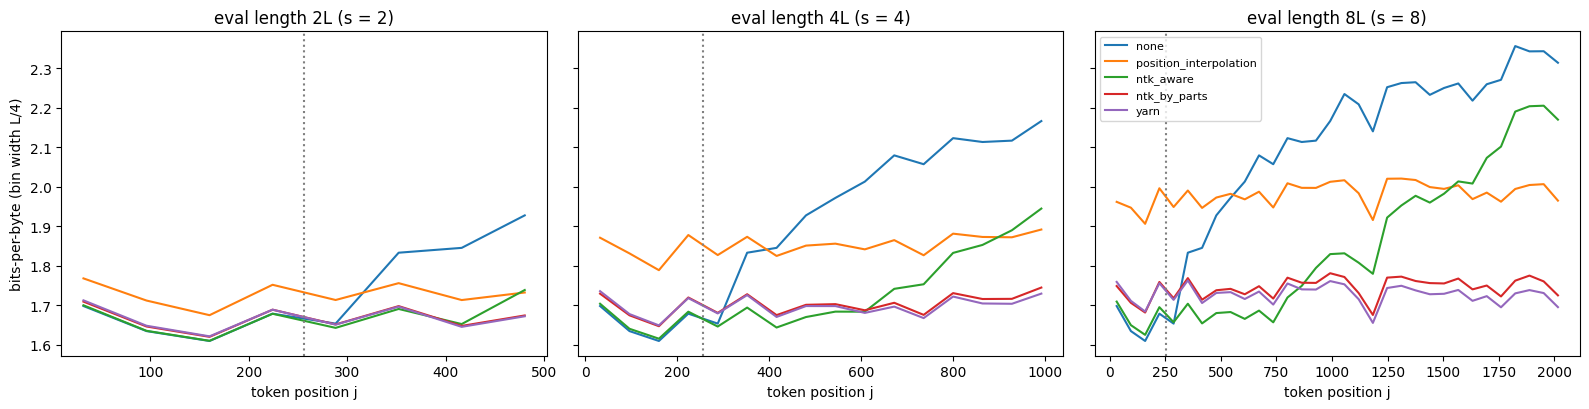

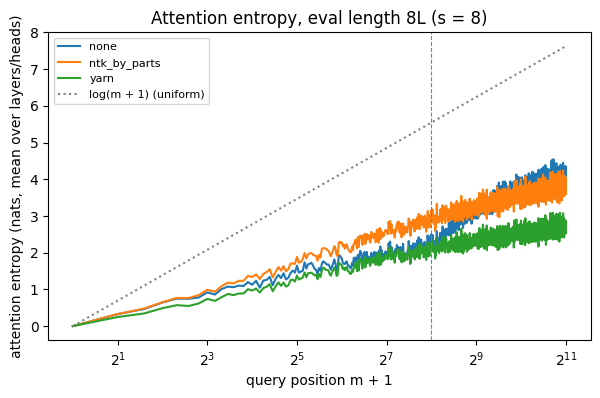

(診断量) エントロピー          none: Query の位置 [L/2, L) の平均 2.0973、[4L, 8L) の平均 4.0129 nats
(診断量) エントロピー  ntk_by_parts: Query の位置 [L/2, L) の平均 2.7479、[4L, 8L) の平均 3.7003 nats
(診断量) エントロピー          yarn: Query の位置 [L/2, L) の平均 1.9767、[4L, 8L) の平均 2.6161 nats


In [14]:
def three_way_verdict(value: float, sigma: float) -> str:
    if not (math.isfinite(value) and math.isfinite(sigma)):
        return "判定不能"
    if value - 2 * sigma > 0:
        return "支持"
    if value + 2 * sigma < 0:
        return "反証"
    return "判定不能"


def verdict_label(computed: str, preconditions: list[str]) -> str:
    return computed if all(precondition_status.get(p) for p in preconditions) else "前提不成立"


def bootstrap_difference_std(
    rows_a: list, rows_b: list, byte_counts: np.ndarray, seed: int, clusters: list
) -> float:
    # 記事を単位とする対応付きのクラスタブートストラップで、mean_k(比 a_k) - mean_k(比 b_k) の標本標準偏差を返す
    # (全行に同じ再標本。判定に使う新基準)。
    k = len(rows_a)
    samples = paired_cluster_bootstrap_ratio_of_sums(
        np.stack(list(rows_a) + list(rows_b)), byte_counts, clusters, BOOTSTRAP_RESAMPLES, seed
    )
    return float((samples[:, :k].mean(axis=1) - samples[:, k:].mean(axis=1)).std(ddof=1))


def window_bootstrap_difference_std(
    rows_a: list, rows_b: list, byte_counts: np.ndarray, seed: int
) -> float:
    # 評価窓を単位とする対応付きブートストラップでの同じ量(旧基準、判定に使わない診断量)。
    k = len(rows_a)
    samples = paired_bootstrap_ratio_of_sums(
        np.stack(list(rows_a) + list(rows_b)), byte_counts, BOOTSTRAP_RESAMPLES, seed
    )
    return float((samples[:, :k].mean(axis=1) - samples[:, k:].mean(axis=1)).std(ddof=1))


def print_per_article(label: str, rows_a: list, rows_b: list, byte_counts: np.ndarray) -> None:
    # 記事ごとの mean_k(比 a_k) - mean_k(比 b_k) と記事ごとの評価窓の数(診断量)。
    articles = np.array(WINDOW_ARTICLES)
    parts = []
    for article in dict.fromkeys(WINDOW_ARTICLES):
        mask = articles == article
        diff = np.mean(
            [
                bits_per_byte(a[mask], byte_counts[mask])
                - bits_per_byte(b[mask], byte_counts[mask])
                for a, b in zip(rows_a, rows_b, strict=True)
            ]
        )
        parts.append(f"{article}: {diff:+.4f}({int(mask.sum())} 窓)")
    print(f"(診断量)記事ごとの {label}: " + "、".join(parts))


# クラスタブートストラップの確認: 全クラスタが 1 単位なら、単位を復元抽出するブートストラップと完全に一致する
_rng = np.random.default_rng(0)
_num, _den = _rng.random((2, 9)), _rng.random(9) + 1
assert np.allclose(  # 乱数の抽出は同一。行列積の配置の違いによる丸め誤差のみを許す
    paired_cluster_bootstrap_ratio_of_sums(_num, _den, list(range(9)), 200, 5),
    paired_bootstrap_ratio_of_sums(_num, _den, 200, 5),
    rtol=1e-12,
    atol=0.0,
)
print(
    "クラスタが 1 単位ずつのとき、記事単位と窓単位のブートストラップが一致(相対誤差 1e-12 以内): OK"
)

_t0 = time.time()
for _factor in EVAL_LENGTH_FACTORS:
    for _method in EVAL_METHODS:
        base_losses(_method, _factor)
print(
    f"実験 A の評価: {len(EVAL_METHODS)} 手法 x {len(EVAL_LENGTH_FACTORS)} 長さ、{time.time() - _t0:.1f}s"
)

# --- 判定(4L、位置 [L, 4L)) ---
BYTES_A = range_bytes(TARGET_BYTES, L, MAIN_FACTOR * L)
BITS_A = {m: range_bits(base_losses(m, MAIN_FACTOR), L, MAIN_FACTOR * L) for m in EVAL_METHODS}
DELTA_A = bits_per_byte(BITS_A["position_interpolation"], BYTES_A) - bits_per_byte(
    BITS_A["yarn"], BYTES_A
)
SIGMA_A = bootstrap_difference_std(
    [BITS_A["position_interpolation"]], [BITS_A["yarn"]], BYTES_A, seed=0, clusters=WINDOW_ARTICLES
)
SIGMA_A_WINDOW = window_bootstrap_difference_std(
    [BITS_A["position_interpolation"]], [BITS_A["yarn"]], BYTES_A, seed=0
)
verdict_A = three_way_verdict(DELTA_A, SIGMA_A)
print(
    f"{_smoke_tag}Delta_A = b_interp - b_yarn = {DELTA_A:+.4f}, sigma_A = {SIGMA_A:.4f}, "
    f"[Delta - 2 sigma, Delta + 2 sigma] = [{DELTA_A - 2 * SIGMA_A:+.4f}, {DELTA_A + 2 * SIGMA_A:+.4f}] "
    f"-> 判定関数の結果: {verdict_A}"
)
print(f"(診断量)旧基準(評価窓を単位とするブートストラップ)の sigma_A = {SIGMA_A_WINDOW:.4f}")
print_per_article(
    "b_interp - b_yarn(4L、[L, 4L))", [BITS_A["position_interpolation"]], [BITS_A["yarn"]], BYTES_A
)

# --- 診断量: 手法 x 評価長の bits-per-byte([0, L) と [L, sL))と、2L・8L での同じ対比量 ---
print(f"\n{'手法':>24} | " + " | ".join(f"{f}L: [0,L) / [L,{f}L)" for f in EVAL_LENGTH_FACTORS))
for _method in EVAL_METHODS:
    _cells = []
    for _factor in EVAL_LENGTH_FACTORS:
        _losses = base_losses(_method, _factor)
        _in = bits_per_byte(range_bits(_losses, 0, L), range_bytes(TARGET_BYTES, 0, L))
        _out = bits_per_byte(
            range_bits(_losses, L, _factor * L), range_bytes(TARGET_BYTES, L, _factor * L)
        )
        _cells.append(f"{_in:.4f} / {_out:.4f}")
    print(f"{_method:>24} | " + " | ".join(f"{c:>17}" for c in _cells))
for _factor in EVAL_LENGTH_FACTORS:
    _bytes = range_bytes(TARGET_BYTES, L, _factor * L)
    _bi = range_bits(base_losses("position_interpolation", _factor), L, _factor * L)
    _by = range_bits(base_losses("yarn", _factor), L, _factor * L)
    _delta = bits_per_byte(_bi, _bytes) - bits_per_byte(_by, _bytes)
    _sigma = bootstrap_difference_std([_bi], [_by], _bytes, seed=_factor, clusters=WINDOW_ARTICLES)
    print(f"(診断量) {_factor}L: b_interp - b_yarn = {_delta:+.4f}, sigma = {_sigma:.4f}")

# --- 診断量: 位置の区間ごとの bits-per-byte の曲線 ---
fig, axes = plt.subplots(1, len(EVAL_LENGTH_FACTORS), figsize=(16, 4.2), sharey=True)
for _ax, _factor in zip(axes, EVAL_LENGTH_FACTORS, strict=True):
    _edges = list(range(0, _factor * L + 1, POSITION_BIN))
    for _method in EVAL_METHODS:
        _losses = base_losses(_method, _factor)
        _curve = [
            bits_per_byte(range_bits(_losses, a, c), range_bytes(TARGET_BYTES, a, c))
            for a, c in zip(_edges[:-1], _edges[1:], strict=True)
        ]
        _ax.plot(
            [(a + c) / 2 for a, c in zip(_edges[:-1], _edges[1:], strict=True)],
            _curve,
            label=_method,
        )
    _ax.axvline(L, color="gray", linestyle=":")
    _ax.set_title(f"{_plot_tag}eval length {_factor}L (s = {_factor})")
    _ax.set_xlabel("token position j")
axes[0].set_ylabel("bits-per-byte (bin width L/4)")
axes[-1].legend(fontsize=8)
fig.tight_layout()
plt.show()


# --- 診断量: Attention のエントロピーの位置依存性(温度の補正の有無) ---
def attention_entropy_by_position(model: GPTLanguageModel, windows: torch.Tensor) -> np.ndarray:
    # 各 Query の位置での注意の分布のエントロピー(nats)を、層・ヘッド・窓で平均する。形状 (層, 長さ)。
    sums = [None] * len(model.blocks)
    handles = []
    for layer_index, block in enumerate(model.blocks):

        def hook(module, inputs, output, i=layer_index):
            weights = output[1]  # (B, h, S, S)
            entropy = -torch.special.xlogy(weights, weights).sum(-1).mean(dim=(0, 1))  # (S,)
            sums[i] = entropy if sums[i] is None else sums[i] + entropy

        handles.append(block.self_attn.register_forward_hook(hook))
    try:
        model.eval()
        with torch.no_grad():
            for window in windows:
                model(window[None].to(device))
    finally:
        for handle in handles:
            handle.remove()
    return torch.stack(sums).float().cpu().numpy().astype(np.float64) / len(windows)


ENTROPY_METHODS = ("none", "ntk_by_parts", "yarn")
ENTROPY = {}
for _method in ENTROPY_METHODS:
    set_rotary(base_model, _method, MAX_FACTOR)
    ENTROPY[_method] = attention_entropy_by_position(base_model, EVAL_WINDOWS[:ENTROPY_WINDOWS])
_query_positions = np.arange(MAX_FACTOR * L)
fig, ax = plt.subplots(figsize=(7, 4))
for _method in ENTROPY_METHODS:
    ax.plot(_query_positions + 1, ENTROPY[_method].mean(axis=0), label=_method)
ax.plot(
    _query_positions + 1,
    np.log(_query_positions + 1),
    color="gray",
    linestyle=":",
    label="log(m + 1) (uniform)",
)
ax.axvline(L, color="gray", linestyle="--", linewidth=0.8)
ax.set_xscale("log", base=2)
ax.set_xlabel("query position m + 1")
ax.set_ylabel("attention entropy (nats, mean over layers/heads)")
ax.set_title(f"{_plot_tag}Attention entropy, eval length {MAX_FACTOR}L (s = {MAX_FACTOR})")
ax.legend(fontsize=8)
plt.show()
for _method in ENTROPY_METHODS:
    _mean = ENTROPY[_method].mean(axis=0)
    print(
        f"(診断量) エントロピー {_method:>13}: Query の位置 [L/2, L) の平均 {_mean[L // 2 : L].mean():.4f}、"
        f"[4L, 8L) の平均 {_mean[4 * L : 8 * L].mean():.4f} nats"
    )

### 6.5 学習率の較正と gradient clipping の閾値(実験 B)

6.1 節の手順どおり、判定に使う 2 手法ごとに学習率のグリッドを本番と同じステップ数で掃引する。診断用の底の調整の条件には、
YaRN で採用した学習率と閾値を使う。

In [15]:
calibration_log: dict[str, dict] = {}
LEARNING_RATE: dict[str, float] = {}
CLIP_THRESHOLD: dict[str, float] = {}
_t0_calibration = time.time()
for _method in JUDGED_FINETUNE_METHODS:
    _results: dict[int, dict] = {}
    _grid = list(LEARNING_RATE_GRID_K)
    _expansions = 0
    while True:
        for _k in _grid:
            if _k in _results:
                continue
            _rec = run_finetune(
                _method,
                CALIBRATION_SEED,
                learning_rate_from_k(_k),
                None,
                FINETUNE_STEPS,
                evaluate=False,
            )
            _results[_k] = {
                "learning_rate": learning_rate_from_k(_k),
                "calibration_bits_per_byte": _rec["calibration_bits_per_byte"],
                "gradient_norm_quantile": float(np.quantile(_rec["gradient_norm"], CLIP_QUANTILE)),
                "all_finite": _rec["all_finite"],
            }
            print(
                f"[{_method}] lr = {learning_rate_from_k(_k):.2e}: 較正用の窓の [L, 4L) の bits-per-byte = "
                f"{_rec['calibration_bits_per_byte']:.4f}"
            )
        _finite = {
            k: r
            for k, r in _results.items()
            if r["all_finite"] and math.isfinite(r["calibration_bits_per_byte"])
        }
        assert _finite, f"{_method}: 全ての学習率で損失が非有限"
        _best = min(_finite, key=lambda k: _finite[k]["calibration_bits_per_byte"])
        if _expansions < MAX_GRID_EXPANSIONS and _best == min(_grid):
            _grid.insert(0, min(_grid) - 1)
            _expansions += 1
            continue
        if _expansions < MAX_GRID_EXPANSIONS and _best == max(_grid):
            _grid.append(max(_grid) + 1)
            _expansions += 1
            continue
        break
    calibration_log[_method] = {
        "grid": {
            f"{learning_rate_from_k(k):.6g}": _results[k]["calibration_bits_per_byte"]
            for k in sorted(_results)
        },
        "chosen_learning_rate": learning_rate_from_k(_best),
        "chosen_is_interior": min(_grid) < _best < max(_grid),
        "clip_threshold": _results[_best]["gradient_norm_quantile"],
    }
    LEARNING_RATE[_method] = learning_rate_from_k(_best)
    CLIP_THRESHOLD[_method] = _results[_best]["gradient_norm_quantile"]
    print(
        f"[{_method}] 採用: lr = {LEARNING_RATE[_method]:.2e}(内点: {calibration_log[_method]['chosen_is_interior']})、"
        f"gradient clipping の閾値 = {CLIP_THRESHOLD[_method]:.4f}"
    )
LEARNING_RATE["adjusted_base"] = LEARNING_RATE["yarn"]  # 診断用の条件は較正しない(6.1 節)
CLIP_THRESHOLD["adjusted_base"] = CLIP_THRESHOLD["yarn"]
print(
    f"[adjusted_base] YaRN の値を使う: lr = {LEARNING_RATE['adjusted_base']:.2e}、閾値 = {CLIP_THRESHOLD['adjusted_base']:.4f}"
)
print(f"較正の合計時間: {time.time() - _t0_calibration:.1f}s")

[position_interpolation] lr = 1.00e-04: 較正用の窓の [L, 4L) の bits-per-byte = 1.4407
[position_interpolation] lr = 3.16e-04: 較正用の窓の [L, 4L) の bits-per-byte = 1.4424
[position_interpolation] lr = 1.00e-03: 較正用の窓の [L, 4L) の bits-per-byte = 1.4727
[position_interpolation] lr = 3.16e-05: 較正用の窓の [L, 4L) の bits-per-byte = 1.4739
[position_interpolation] 採用: lr = 1.00e-04(内点: True)、gradient clipping の閾値 = 0.9976
[yarn] lr = 1.00e-04: 較正用の窓の [L, 4L) の bits-per-byte = 1.4180
[yarn] lr = 3.16e-04: 較正用の窓の [L, 4L) の bits-per-byte = 1.4327
[yarn] lr = 1.00e-03: 較正用の窓の [L, 4L) の bits-per-byte = 1.4673
[yarn] lr = 3.16e-05: 較正用の窓の [L, 4L) の bits-per-byte = 1.4161
[yarn] 採用: lr = 3.16e-05(内点: False)、gradient clipping の閾値 = 0.7955
[adjusted_base] YaRN の値を使う: lr = 3.16e-05、閾値 = 0.7955
較正の合計時間: 827.1s


### 6.6 実験 B: 短い微調整の後の比較

[position_interpolation] seed=0: 較正用の窓の損失 4.4623 -> 3.8831 nats、clipping の発動率 0.11
[position_interpolation] seed=1: 較正用の窓の損失 4.4623 -> 3.8863 nats、clipping の発動率 0.12
[position_interpolation] seed=2: 較正用の窓の損失 4.4623 -> 3.8821 nats、clipping の発動率 0.12
[position_interpolation] seed=3: 較正用の窓の損失 4.4623 -> 3.8814 nats、clipping の発動率 0.12
[position_interpolation] seed=4: 較正用の窓の損失 4.4623 -> 3.8901 nats、clipping の発動率 0.10
[yarn] seed=0: 較正用の窓の損失 3.9248 -> 3.8216 nats、clipping の発動率 0.12
[yarn] seed=1: 較正用の窓の損失 3.9248 -> 3.8228 nats、clipping の発動率 0.12
[yarn] seed=2: 較正用の窓の損失 3.9248 -> 3.8210 nats、clipping の発動率 0.11
[yarn] seed=3: 較正用の窓の損失 3.9248 -> 3.8224 nats、clipping の発動率 0.09
[yarn] seed=4: 較正用の窓の損失 3.9248 -> 3.8245 nats、clipping の発動率 0.12
[adjusted_base] seed=0: 較正用の窓の損失 4.0251 -> 3.8299 nats、clipping の発動率 0.17
[adjusted_base] seed=1: 較正用の窓の損失 4.0251 -> 3.8314 nats、clipping の発動率 0.18
本番の微調整の合計時間: 1593.7s
前提条件 P-B1(全条件・全シードで微調整後の損失 < 微調整前): 成立、P-B2(損失が有限・学習率が内点): 不成立
d_k = [0.0071, 0.0071, 0.007

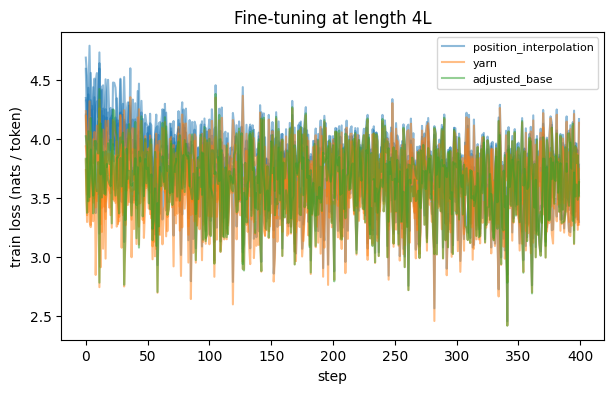

In [16]:
finetune_records: dict[str, list[dict]] = {m: [] for m in FINETUNE_METHODS}
_t0 = time.time()
for _method in FINETUNE_METHODS:
    for _seed in SEEDS if _method in JUDGED_FINETUNE_METHODS else DIAGNOSTIC_SEEDS:
        _rec = run_finetune(
            _method, _seed, LEARNING_RATE[_method], CLIP_THRESHOLD[_method], FINETUNE_STEPS
        )
        finetune_records[_method].append(_rec)
        print(
            f"[{_method}] seed={_seed}: 較正用の窓の損失 {_rec['initial_loss']:.4f} -> {_rec['final_loss']:.4f} nats、"
            f"clipping の発動率 {_rec['clip_trigger_ratio']:.2f}"
        )
print(f"本番の微調整の合計時間: {time.time() - _t0:.1f}s")

_all_finetune = [r for rs in finetune_records.values() for r in rs]
precondition_status["P-B1"] = all(r["final_loss"] < r["initial_loss"] for r in _all_finetune)
precondition_status["P-B2"] = all(r["all_finite"] for r in _all_finetune) and all(
    calibration_log[m]["chosen_is_interior"] for m in JUDGED_FINETUNE_METHODS
)
print(
    f"前提条件 P-B1(全条件・全シードで微調整後の損失 < 微調整前): {'成立' if precondition_status['P-B1'] else '不成立'}、"
    f"P-B2(損失が有限・学習率が内点): {'成立' if precondition_status['P-B2'] else '不成立'}"
)


def seed_bits(method: str, start: int, end: int, key: str = "eval_losses") -> list[np.ndarray]:
    return [range_bits(r[key], start, end) for r in finetune_records[method]]


def seed_paired_contrast(
    rows_a: list, rows_b: list, byte_counts: np.ndarray, seed: int, clusters: list
) -> dict:
    # シードで対応をとった差 d_k = b(a_k) - b(b_k) の平均と、sigma = sqrt(sigma_seed^2 + sigma_window^2)。
    # sigma_window は記事を単位とするクラスタブートストラップ(新基準)。旧基準の値も診断量として返す。
    differences = np.array(
        [
            bits_per_byte(a, byte_counts) - bits_per_byte(b, byte_counts)
            for a, b in zip(rows_a, rows_b, strict=True)
        ]
    )
    sigma_seed = float(differences.std(ddof=1) / math.sqrt(len(differences)))
    sigma_window = bootstrap_difference_std(rows_a, rows_b, byte_counts, seed, clusters)
    sigma_window_old = window_bootstrap_difference_std(rows_a, rows_b, byte_counts, seed)
    return {
        "delta": float(differences.mean()),
        "differences": differences.tolist(),
        "sigma_seed": sigma_seed,
        "sigma_window": sigma_window,
        "sigma": math.sqrt(sigma_seed**2 + sigma_window**2),
        "sigma_window_old": sigma_window_old,
        "sigma_old": math.sqrt(sigma_seed**2 + sigma_window_old**2),
    }


BYTES_B = range_bytes(TARGET_BYTES, L, FINETUNE_FACTOR * L)
CONTRAST_B = seed_paired_contrast(
    seed_bits("position_interpolation", L, FINETUNE_FACTOR * L),
    seed_bits("yarn", L, FINETUNE_FACTOR * L),
    BYTES_B,
    seed=10,
    clusters=WINDOW_ARTICLES,
)
verdict_B = three_way_verdict(CONTRAST_B["delta"], CONTRAST_B["sigma"])
_yarn_values = [bits_per_byte(b, BYTES_B) for b in seed_bits("yarn", L, FINETUNE_FACTOR * L)]
NOISE_FLOOR_B = float(np.std(_yarn_values, ddof=1))
print(
    f"{_smoke_tag}d_k = {np.round(CONTRAST_B['differences'], 4).tolist()}、Delta_B = {CONTRAST_B['delta']:+.4f}、"
    f"sigma_seed = {CONTRAST_B['sigma_seed']:.4f}、sigma_window = {CONTRAST_B['sigma_window']:.4f}、"
    f"sigma_B = {CONTRAST_B['sigma']:.4f} -> 判定関数の結果: {verdict_B}"
)
print(
    f"{_smoke_tag}ノイズ床(YaRN + 微調整の bits-per-byte のシード間の標本標準偏差): {NOISE_FLOOR_B:.4f}"
)
print(
    f"(診断量)旧基準の sigma_window = {CONTRAST_B['sigma_window_old']:.4f}、"
    f"sigma_B = {CONTRAST_B['sigma_old']:.4f}"
)
print_per_article(
    "シード平均の b_interp - b_yarn(微調整後、[L, 4L))",
    seed_bits("position_interpolation", L, FINETUNE_FACTOR * L),
    seed_bits("yarn", L, FINETUNE_FACTOR * L),
    BYTES_B,
)

# --- 診断量 ---
print(f"\n{'手法 + 微調整':>24} | {'[0, L)':>15} | {'[L, 4L)':>15}(シード平均 ± 標本標準偏差)")
for _method in FINETUNE_METHODS:
    _cells = []
    for _a, _c in ((0, L), (L, FINETUNE_FACTOR * L)):
        _values = [
            bits_per_byte(b, range_bytes(TARGET_BYTES, _a, _c)) for b in seed_bits(_method, _a, _c)
        ]
        _cells.append(f"{np.mean(_values):.4f} ± {np.std(_values, ddof=1):.4f}")
    print(f"{_method:>24} | " + " | ".join(f"{c:>15}" for c in _cells))
for _method in ("none", "position_interpolation", "yarn"):
    _losses = base_losses(_method, FINETUNE_FACTOR)
    print(
        f"(比較)微調整なし {_method:>22}: [0, L) {bits_per_byte(range_bits(_losses, 0, L), range_bytes(TARGET_BYTES, 0, L)):.4f}、"
        f"[L, 4L) {bits_per_byte(range_bits(_losses, L, 4 * L), BYTES_B):.4f}"
    )
fig, ax = plt.subplots(figsize=(7, 4))
for _method in FINETUNE_METHODS:
    for _i, _r in enumerate(finetune_records[_method]):
        ax.plot(
            _r["train_loss"],
            color=f"C{FINETUNE_METHODS.index(_method)}",
            alpha=0.5,
            label=_method if _i == 0 else None,
        )
ax.set_xlabel("step")
ax.set_ylabel("train loss (nats / token)")
ax.set_title(f"{_plot_tag}Fine-tuning at length {FINETUNE_FACTOR}L")
ax.legend(fontsize=8)
plt.show()

### 6.7 実験 C: 伸ばした文脈を実際に使っているか

In [17]:
precondition_status["P-C1"] = WINDOWS_WITHIN_ARTICLE
_start_c, _end_c = (FINETUNE_FACTOR - 1) * L, FINETUNE_FACTOR * L
BYTES_C = range_bytes(TARGET_BYTES, _start_c, _end_c)


def truncated_bits(losses: np.ndarray) -> np.ndarray:
    return losses.sum(axis=1) / LOG2


CONTRAST_C = seed_paired_contrast(
    [truncated_bits(r["truncated_losses"]) for r in finetune_records["yarn"]],
    seed_bits("yarn", _start_c, _end_c),
    BYTES_C,
    seed=20,
    clusters=WINDOW_ARTICLES,
)
verdict_C = three_way_verdict(CONTRAST_C["delta"], CONTRAST_C["sigma"])
print(
    f"前提条件 P-C1(全評価窓が 1 つの記事の中): {'成立' if precondition_status['P-C1'] else '不成立'}"
)
print(
    f"{_smoke_tag}c_k = {np.round(CONTRAST_C['differences'], 4).tolist()}、Delta_C = {CONTRAST_C['delta']:+.4f}、"
    f"sigma_seed = {CONTRAST_C['sigma_seed']:.4f}、sigma_window = {CONTRAST_C['sigma_window']:.4f}、"
    f"sigma_C = {CONTRAST_C['sigma']:.4f} -> 判定関数の結果: {verdict_C}"
)
print(
    f"(診断量)旧基準の sigma_window = {CONTRAST_C['sigma_window_old']:.4f}、"
    f"sigma_C = {CONTRAST_C['sigma_old']:.4f}"
)
print_per_article(
    "シード平均の b_truncated - b_full(YaRN + 微調整、[3L, 4L))",
    [truncated_bits(r["truncated_losses"]) for r in finetune_records["yarn"]],
    seed_bits("yarn", _start_c, _end_c),
    BYTES_C,
)

# --- 診断量: 微調整なしの各手法(s = 4)と、微調整した位置補間 ---
print("\n(診断量)位置 [3L, 4L) の b_truncated - b_full")
for _method in ("none", "position_interpolation", "ntk_aware", "yarn"):

    def _compute(m=_method):
        set_rotary(base_model, m, FINETUNE_FACTOR)
        return truncated_token_losses(base_model, EVAL_WINDOWS, _start_c, _end_c, L)

    _truncated = cached_losses(("base_truncated", _method, FINETUNE_FACTOR), _compute)
    _bits_full = range_bits(base_losses(_method, FINETUNE_FACTOR), _start_c, _end_c)
    _bits_truncated = truncated_bits(_truncated)
    _delta = bits_per_byte(_bits_truncated, BYTES_C) - bits_per_byte(_bits_full, BYTES_C)
    _sigma = bootstrap_difference_std(
        [_bits_truncated], [_bits_full], BYTES_C, seed=21, clusters=WINDOW_ARTICLES
    )
    print(
        f"  微調整なし {_method:>22}: full {bits_per_byte(_bits_full, BYTES_C):.4f}、"
        f"truncated {bits_per_byte(_bits_truncated, BYTES_C):.4f}、差 {_delta:+.4f}(sigma {_sigma:.4f})"
    )
_interp_diagnostic = [
    r for r in finetune_records["position_interpolation"] if "truncated_losses" in r
]
_contrast_interp = seed_paired_contrast(
    [truncated_bits(r["truncated_losses"]) for r in _interp_diagnostic],
    [range_bits(r["eval_losses"], _start_c, _end_c) for r in _interp_diagnostic],
    BYTES_C,
    seed=22,
    clusters=WINDOW_ARTICLES,
)
print(
    f"  位置補間 + 微調整(シード {[r['seed'] for r in _interp_diagnostic]}): 差のシード平均 {_contrast_interp['delta']:+.4f}(sigma {_contrast_interp['sigma']:.4f})、"
    f"シードごと {np.round(_contrast_interp['differences'], 4).tolist()}"
)

前提条件 P-C1(全評価窓が 1 つの記事の中): 成立
c_k = [0.0024, 0.0025, 0.0024, 0.0023, 0.0024]、Delta_C = +0.0024、sigma_seed = 0.0000、sigma_window = 0.0007、sigma_C = 0.0007 -> 判定関数の結果: 支持
(診断量)旧基準の sigma_window = 0.0006、sigma_C = 0.0006
(診断量)記事ごとの シード平均の b_truncated - b_full(YaRN + 微調整、[3L, 4L)): 338: +0.0091(6 窓)、339: -0.0018(7 窓)、340: +0.0038(18 窓)、341: -0.0014(5 窓)、342: +0.0001(16 窓)、343: +0.0005(11 窓)、346: +0.0066(2 窓)、347: +0.0026(8 窓)、349: +0.0000(11 窓)、351: +0.0033(16 窓)、353: -0.0030(4 窓)、355: +0.0038(43 窓)

(診断量)位置 [3L, 4L) の b_truncated - b_full
  微調整なし                   none: full 2.1297、truncated 1.6806、差 -0.4491(sigma 0.0108)
  微調整なし position_interpolation: full 1.8797、truncated 1.8688、差 -0.0109(sigma 0.0014)
  微調整なし              ntk_aware: full 1.8801、truncated 1.6851、差 -0.1950(sigma 0.0091)
  微調整なし                   yarn: full 1.7153、truncated 1.7190、差 +0.0037(sigma 0.0011)
  位置補間 + 微調整(シード [0, 1]): 差のシード平均 +0.0014(sigma 0.0008)、シードごと [0.0013, 0.0015]


### 6.8 実験 D: 静的なスケーリングの短い系列でのコスト

In [18]:
CHUNKS = EVAL_WINDOWS.reshape(-1, L)  # (窓 x 8, L): 各窓を 8 個の長さ L の区間に分ける
_chunk_target_bytes = TOKEN_BYTE_LENGTHS[CHUNKS[:, 1:].numpy()]
BYTES_D = (
    _chunk_target_bytes.reshape(NUM_EVAL_WINDOWS, MAX_FACTOR, L - 1)
    .sum(axis=(1, 2))
    .astype(np.float64)
)


def chunk_losses(method: str, scale: float) -> np.ndarray:
    def compute():
        set_rotary(base_model, method, scale)
        return token_losses(base_model, CHUNKS)

    return cached_losses(("base_chunks", method, scale), compute)


def chunk_bits_per_window(losses: np.ndarray) -> np.ndarray:
    # 窓(長さ 8L)を単位として、その 8 区間の損失の合計(ビット)
    return losses.reshape(NUM_EVAL_WINDOWS, MAX_FACTOR, L - 1).sum(axis=(1, 2)) / LOG2


BITS_D = {
    "none": chunk_bits_per_window(chunk_losses("none", 1)),
    "yarn": chunk_bits_per_window(chunk_losses("yarn", MAIN_FACTOR)),
    "position_interpolation": chunk_bits_per_window(
        chunk_losses("position_interpolation", MAIN_FACTOR)
    ),
}
DELTA_D = bits_per_byte(BITS_D["yarn"], BYTES_D) - bits_per_byte(BITS_D["none"], BYTES_D)
SIGMA_D = bootstrap_difference_std(
    [BITS_D["yarn"]], [BITS_D["none"]], BYTES_D, seed=30, clusters=WINDOW_ARTICLES
)
SIGMA_D_WINDOW = window_bootstrap_difference_std(
    [BITS_D["yarn"]], [BITS_D["none"]], BYTES_D, seed=30
)
verdict_D = three_way_verdict(DELTA_D, SIGMA_D)
print(
    f"{_smoke_tag}Delta_D = b_yarn(s=4) - b_none = {DELTA_D:+.4f}, sigma_D = {SIGMA_D:.4f} "
    f"-> 判定関数の結果: {verdict_D}"
)
print(f"(診断量)旧基準(評価窓を単位とするブートストラップ)の sigma_D = {SIGMA_D_WINDOW:.4f}")
print_per_article("b_yarn(s=4) - b_none(長さ L)", [BITS_D["yarn"]], [BITS_D["none"]], BYTES_D)

# --- dynamic YaRN は長さ L の区間でスケーリングなしと完全に一致する(アサーション) ---
_dynamic_losses = chunk_losses("dynamic_yarn", 1)
assert np.array_equal(_dynamic_losses, chunk_losses("none", 1)), (
    "dynamic YaRN が l <= L でスケーリングなしと一致しない"
)
set_rotary(base_model, "dynamic_yarn", 1)
with torch.no_grad():
    _logits_dynamic = base_model(CHUNKS[:4].to(device))
set_rotary(base_model, "none", 1)
with torch.no_grad():
    _logits_none = base_model(CHUNKS[:4].to(device))
assert torch.equal(_logits_dynamic, _logits_none)
print("dynamic YaRN: 長さ L の全区間の損失と logits がスケーリングなしと完全一致: OK")

# --- 診断量 ---
_delta_interp = bits_per_byte(BITS_D["position_interpolation"], BYTES_D) - bits_per_byte(
    BITS_D["none"], BYTES_D
)
print(
    f"(診断量)長さ L: b_none = {bits_per_byte(BITS_D['none'], BYTES_D):.4f}、b_yarn(s=4) = "
    f"{bits_per_byte(BITS_D['yarn'], BYTES_D):.4f}、b_interp(s=4) = {bits_per_byte(BITS_D['position_interpolation'], BYTES_D):.4f}"
    f"(b_interp - b_none = {_delta_interp:+.4f}、sigma "
    f"{bootstrap_difference_std([BITS_D['position_interpolation']], [BITS_D['none']], BYTES_D, seed=31, clusters=WINDOW_ARTICLES):.4f})"
)
print(
    f"(診断量)P0 との比較: 記事の中の長さ L の区間でのスケーリングなし {bits_per_byte(BITS_D['none'], BYTES_D):.4f}、"
    f"P0 の評価集合 {P0_BITS_PER_BYTE:.4f}"
)


def dynamic_prefix_losses() -> np.ndarray:
    # 位置 j in [(c-1)L, cL) を、先頭から cL トークンの系列(dynamic により s = c)で予測する(c = 1..4)。
    set_rotary(base_model, "dynamic_yarn", 1)
    out = np.empty((NUM_EVAL_WINDOWS, FINETUNE_FACTOR * L - 1))
    for c in range(1, FINETUNE_FACTOR + 1):
        losses = token_losses(base_model, EVAL_WINDOWS[:, : c * L])
        lo, hi = max((c - 1) * L, 1) - 1, c * L - 1
        out[:, lo:hi] = losses[:, lo:hi]
    return out


_dynamic_prefix = cached_losses(("base_dynamic_prefix", FINETUNE_FACTOR), dynamic_prefix_losses)
assert np.allclose(
    _dynamic_prefix[:, : L - 1], base_losses("none", FINETUNE_FACTOR)[:, : L - 1], atol=1e-4
)
_bytes = range_bytes(TARGET_BYTES, L, FINETUNE_FACTOR * L)
_bits_dynamic = range_bits(_dynamic_prefix, L, FINETUNE_FACTOR * L)
_bits_static = range_bits(base_losses("yarn", FINETUNE_FACTOR), L, FINETUNE_FACTOR * L)
print(
    f"(診断量)位置 [L, 4L): dynamic YaRN(前方からの評価){bits_per_byte(_bits_dynamic, _bytes):.4f}、"
    f"静的な YaRN(s=4){bits_per_byte(_bits_static, _bytes):.4f}、差 "
    f"{bits_per_byte(_bits_dynamic, _bytes) - bits_per_byte(_bits_static, _bytes):+.4f}"
    f"(sigma {bootstrap_difference_std([_bits_dynamic], [_bits_static], _bytes, seed=32, clusters=WINDOW_ARTICLES):.4f})"
)

Delta_D = b_yarn(s=4) - b_none = +0.0407, sigma_D = 0.0018 -> 判定関数の結果: 支持
(診断量)旧基準(評価窓を単位とするブートストラップ)の sigma_D = 0.0008
(診断量)記事ごとの b_yarn(s=4) - b_none(長さ L): 338: +0.0418(6 窓)、339: +0.0447(7 窓)、340: +0.0382(18 窓)、341: +0.0433(5 窓)、342: +0.0369(16 窓)、343: +0.0370(11 窓)、346: -0.0058(2 窓)、347: +0.0437(8 窓)、349: +0.0453(11 窓)、351: +0.0408(16 窓)、353: +0.0159(4 窓)、355: +0.0457(43 窓)
dynamic YaRN: 長さ L の全区間の損失と logits がスケーリングなしと完全一致: OK
(診断量)長さ L: b_none = 1.6752、b_yarn(s=4) = 1.7160、b_interp(s=4) = 1.8619(b_interp - b_none = +0.1867、sigma 0.0049)
(診断量)P0 との比較: 記事の中の長さ L の区間でのスケーリングなし 1.6752、P0 の評価集合 1.6681
(診断量)位置 [L, 4L): dynamic YaRN(前方からの評価)1.6854、静的な YaRN(s=4)1.6983、差 -0.0129(sigma 0.0006)


### 6.9 不変条件のアサーションと`SMOKE_TEST`の配線

- 全ての微調整の記録で、評価窓(ハッシュ)・ステップ数・学習履歴の長さが同一であり、トークン数がエポックの上限を超えない。
- 判定に使う量の分母(バイト数)は、条件によらず評価窓のトークンだけから計算した同じ配列である。実験 A・B で共通の範囲の
  分母が一致すること。
- 再利用した損失(`LOSS_CACHE`)が、キャッシュを経由せずに計算し直した値と完全に一致すること(冗長な再計算の排除の前後で
  数値が変わらない)。
- ベースモデルの重みが、全ての実験の後も Hub から読み込んだ重みと完全に一致すること(微調整は複製に対して行った)。
- `SMOKE_TEST`の配線: 実際に使った評価窓の数・シード数・ステップ数・反復回数が、5.3 節の実効水準と一致すること。

In [19]:
for _r in _all_finetune:
    assert _r["eval_windows_hash"] == EVAL_WINDOWS_HASH, "評価窓が条件間で異なる"
    assert _r["num_steps"] == FINETUNE_STEPS == _r["history_length"], "ステップ数が条件間で異なる"
    assert _r["num_steps"] * TOKENS_PER_STEP <= len(finetune_ids), "エポックの上限を超えた"
    assert _r["eval_losses"].shape == (NUM_EVAL_WINDOWS, FINETUNE_FACTOR * L - 1)
for _r in _all_finetune:  # 切り詰めた評価は YaRN の全シードと位置補間の診断用のシードのみ
    _expected_truncated = _r["method"] == "yarn" or (
        _r["method"] == "position_interpolation" and _r["seed"] in DIAGNOSTIC_SEEDS
    )
    assert ("truncated_losses" in _r) == _expected_truncated
    if _expected_truncated:
        assert _r["truncated_losses"].shape == (NUM_EVAL_WINDOWS, L)
assert np.array_equal(BYTES_A, BYTES_B), "実験 A・B の分母が一致しない"
assert all(
    base_losses(m, f).shape == (NUM_EVAL_WINDOWS, f * L - 1)
    for m in EVAL_METHODS
    for f in EVAL_LENGTH_FACTORS
)
print(
    f"微調整の全 {len(_all_finetune)} 回: 評価窓・ステップ数({FINETUNE_STEPS})・エポックの上限・形状: OK"
)

# --- 冗長な再計算の排除の前後で数値が変わらないこと ---
set_rotary(base_model, "yarn", MAIN_FACTOR)
assert np.array_equal(
    token_losses(base_model, EVAL_WINDOWS[:, : MAIN_FACTOR * L]), base_losses("yarn", MAIN_FACTOR)
)
set_rotary(base_model, "none", 1)
assert np.array_equal(token_losses(base_model, CHUNKS), chunk_losses("none", 1))
print(f"キャッシュした損失({len(LOSS_CACHE)} 件)を計算し直した値と完全一致: OK")

# --- ベースモデルが変化していないこと ---
_hub_state = torch.load(MODEL_STATE_PATH, map_location="cpu")
assert all(torch.equal(v.cpu(), _hub_state[k]) for k, v in base_model.state_dict().items())
print("ベースモデルの重みが Hub から読み込んだ重みと完全一致: OK")

# --- SMOKE_TEST の配線 ---
_expected_windows = (
    len(EVAL_WINDOWS_ALL)
    if MAX_EVAL_WINDOWS is None
    else min(MAX_EVAL_WINDOWS, len(EVAL_WINDOWS_ALL))
)
assert NUM_EVAL_WINDOWS == _expected_windows == len(BYTES_A) == len(BYTES_D)
assert all([r["seed"] for r in finetune_records[m]] == list(SEEDS) for m in JUDGED_FINETUNE_METHODS)
assert [r["seed"] for r in finetune_records["adjusted_base"]] == list(DIAGNOSTIC_SEEDS)
assert NUM_EVAL_ARTICLES == len(set(WINDOW_ARTICLES)) >= 2
assert all(
    len(calibration_log[m]["grid"]) <= len(LEARNING_RATE_GRID_K) + MAX_GRID_EXPANSIONS
    for m in calibration_log
)
assert len(SEEDS) == CFG["NUM_SEEDS"] and CFG["FINETUNE_STEPS"] == FINETUNE_STEPS
assert len(calibration_windows) == CFG["CALIBRATION_WINDOWS"]
assert all(len(ENTROPY[m]) == NUM_LAYERS for m in ENTROPY_METHODS)
_probe = paired_bootstrap_ratio_of_sums(np.stack([BITS_A["yarn"]]), BYTES_A, BOOTSTRAP_RESAMPLES, 0)
assert _probe.shape == (CFG["BOOTSTRAP_RESAMPLES"], 1)
print(
    f"SMOKE_TEST の配線: 水準 {CURRENT_LEVEL_NAME!r}(評価窓 {NUM_EVAL_WINDOWS}・記事 {NUM_EVAL_ARTICLES} 本、"
    f"シード {len(SEEDS)}(診断用 {len(DIAGNOSTIC_SEEDS)})、"
    f"ステップ {FINETUNE_STEPS}、較正用の窓 {len(calibration_windows)}、反復 {BOOTSTRAP_RESAMPLES})が実効水準と一致: OK"
)

微調整の全 12 回: 評価窓・ステップ数(400)・エポックの上限・形状: OK
キャッシュした損失(24 件)を計算し直した値と完全一致: OK
ベースモデルの重みが Hub から読み込んだ重みと完全一致: OK
SMOKE_TEST の配線: 水準 'prod'(評価窓 147・記事 12 本、シード 5(診断用 2)、ステップ 400、較正用の窓 32、反復 10000)が実効水準と一致: OK


### 6.10 判定の一次情報(全件)

判定の一次情報(事前宣言した対比量と前提条件を再計算できる最小の量)を全件印字する。

- `windows`: 評価窓ごとのマニフェストの番号(記事の識別子。記事を単位とするブートストラップのクラスタ)・区間の中での
  トークンの位置(前提条件 P-C1 の根拠)。
- `p0`: P0 の bits-per-byte とモデルカードの値。
- `experiment_A`: 評価窓ごとの、評価長 $4L$ の位置 $[L, 4L)$ の損失の合計(ビット)(位置補間・YaRN)と分母(バイト)。
- `experiment_B`: 判定に使う 2 手法の学習率・閾値の採用結果(較正のグリッドの値を含む)、手法 × シードごとの学習前後の損失(P-B1)・有限性(P-B2)、
  判定に使う 2 手法 × シードごとの、評価窓ごとの位置 $[L, 4L)$ の損失の合計(ビット)。分母は実験 A と同じ。
- `experiment_C`: YaRN + 微調整のシードごとの、評価窓ごとの位置 $[3L, 4L)$ の損失の合計(全文脈・切り詰め)と分母。
- `experiment_D`: 評価窓ごとの、8 区間の損失の合計(スケーリングなし・静的な YaRN)と分母。

位置ごとの損失・曲線・エントロピー・診断用の条件は判定に使わないので含めない(6.4〜6.8 節で印字している)。

**一次情報だけからの再計算**: 印字した文字列を JSON として読み戻したデータのみを使って、前提条件と全実験の対比量・標準偏差・
判定を再計算し、判定に使った値と一致することをアサーションで確かめる。

In [20]:
def _floats(values) -> list[float]:
    return [float(v) for v in values]


primary_data = {
    "smoke_test": SMOKE_TEST,
    "bootstrap_resamples": BOOTSTRAP_RESAMPLES,
    "windows": {
        "manifest_index": [i["manifest_index"] for i in WINDOW_INFO],
        "token_offset": [i["token_offset"] for i in WINDOW_INFO],
        "segment_tokens": [i["segment_tokens"] for i in WINDOW_INFO],
        "window_length": MAX_FACTOR * L,
    },
    "p0": {
        "bits_per_byte": P0_BITS_PER_BYTE,
        "model_card": MODEL_CARD_BITS_PER_BYTE,
        "tolerance": P0_TOLERANCE,
    },
    "experiment_A": {
        "bytes": _floats(BYTES_A),
        "position_interpolation_bits": _floats(BITS_A["position_interpolation"]),
        "yarn_bits": _floats(BITS_A["yarn"]),
    },
    "experiment_B": {
        "calibration": calibration_log,
        "runs": {
            m: {
                "seed": [r["seed"] for r in finetune_records[m]],
                "initial_loss": [r["initial_loss"] for r in finetune_records[m]],
                "final_loss": [r["final_loss"] for r in finetune_records[m]],
                "all_finite": [r["all_finite"] for r in finetune_records[m]],
            }
            for m in FINETUNE_METHODS
        },
        **{
            f"{m}_bits": [_floats(b) for b in seed_bits(m, L, FINETUNE_FACTOR * L)]
            for m in JUDGED_FINETUNE_METHODS
        },
    },
    "experiment_C": {
        "bytes": _floats(BYTES_C),
        "full_bits": [_floats(b) for b in seed_bits("yarn", _start_c, _end_c)],
        "truncated_bits": [
            _floats(truncated_bits(r["truncated_losses"])) for r in finetune_records["yarn"]
        ],
    },
    "experiment_D": {
        "bytes": _floats(BYTES_D),
        "none_bits": _floats(BITS_D["none"]),
        "yarn_bits": _floats(BITS_D["yarn"]),
    },
}

PRIMARY_DATA_TEXT = dumps_compact_json(primary_data)
print(PRIMARY_DATA_TEXT)
assert json.loads(PRIMARY_DATA_TEXT) == json.loads(json.dumps(primary_data)), "整形で情報が落ちた"
_long_lines = [len(line) for line in PRIMARY_DATA_TEXT.splitlines() if len(line) > 100]
assert not _long_lines, f"100 文字を超える行がある: {_long_lines[:10]}"
print(
    f"\n判定の一次情報の出力: {len(PRIMARY_DATA_TEXT.splitlines()):,} 行・{len(PRIMARY_DATA_TEXT):,} 文字"
)


# --- 一次情報だけからの再計算(印字した文字列を読み戻したデータのみを使う) ---
def _close(a: float, b: float) -> bool:
    return math.isclose(a, b, rel_tol=1e-9, abs_tol=1e-12)


_loaded = json.loads(PRIMARY_DATA_TEXT)
assert (
    abs(_loaded["p0"]["bits_per_byte"] - _loaded["p0"]["model_card"]) <= _loaded["p0"]["tolerance"]
) == precondition_status["P0"]
_la = _loaded["experiment_A"]
_bytes = np.array(_la["bytes"])
_delta = bits_per_byte(np.array(_la["position_interpolation_bits"]), _bytes) - bits_per_byte(
    np.array(_la["yarn_bits"]), _bytes
)
_clusters = _loaded["windows"]["manifest_index"]
_sigma = bootstrap_difference_std(
    [np.array(_la["position_interpolation_bits"])],
    [np.array(_la["yarn_bits"])],
    _bytes,
    seed=0,
    clusters=_clusters,
)
assert (
    _close(_delta, DELTA_A)
    and _close(_sigma, SIGMA_A)
    and three_way_verdict(_delta, _sigma) == verdict_A
)
_lb = _loaded["experiment_B"]
assert (
    all(
        f < i
        for m in FINETUNE_METHODS
        for i, f in zip(_lb["runs"][m]["initial_loss"], _lb["runs"][m]["final_loss"], strict=True)
    )
    == precondition_status["P-B1"]
)
assert (
    all(all(_lb["runs"][m]["all_finite"]) for m in FINETUNE_METHODS)
    and all(_lb["calibration"][m]["chosen_is_interior"] for m in JUDGED_FINETUNE_METHODS)
) == precondition_status["P-B2"]
_c = seed_paired_contrast(
    [np.array(b) for b in _lb["position_interpolation_bits"]],
    [np.array(b) for b in _lb["yarn_bits"]],
    _bytes,
    seed=10,
    clusters=_clusters,
)
assert _close(_c["delta"], CONTRAST_B["delta"]) and _close(_c["sigma"], CONTRAST_B["sigma"])
assert three_way_verdict(_c["delta"], _c["sigma"]) == verdict_B
_lc = _loaded["experiment_C"]
_c = seed_paired_contrast(
    [np.array(b) for b in _lc["truncated_bits"]],
    [np.array(b) for b in _lc["full_bits"]],
    np.array(_lc["bytes"]),
    seed=20,
    clusters=_clusters,
)
assert _close(_c["delta"], CONTRAST_C["delta"]) and _close(_c["sigma"], CONTRAST_C["sigma"])
assert three_way_verdict(_c["delta"], _c["sigma"]) == verdict_C
_lw = _loaded["windows"]
assert (
    all(
        o + _lw["window_length"] <= n
        for o, n in zip(_lw["token_offset"], _lw["segment_tokens"], strict=True)
    )
    == precondition_status["P-C1"]
)
_ld = _loaded["experiment_D"]
_bytes = np.array(_ld["bytes"])
_delta = bits_per_byte(np.array(_ld["yarn_bits"]), _bytes) - bits_per_byte(
    np.array(_ld["none_bits"]), _bytes
)
_sigma = bootstrap_difference_std(
    [np.array(_ld["yarn_bits"])], [np.array(_ld["none_bits"])], _bytes, seed=30, clusters=_clusters
)
assert (
    _close(_delta, DELTA_D)
    and _close(_sigma, SIGMA_D)
    and three_way_verdict(_delta, _sigma) == verdict_D
)
print("一次情報だけからの再計算: 前提条件と全実験の対比量・標準偏差・判定が一致(OK)")

{
  "smoke_test": false,
  "bootstrap_resamples": 10000,
  "windows": {
    "manifest_index": [
      338, 338, 338, 338, 338, 338, 339, 339, 339, 339, 339, 339, 339, 340, 340, 340, 340, 340, 340,
      340, 340, 340, 340, 340, 340, 340, 340, 340, 340, 340, 340, 341, 341, 341, 341, 341, 342, 342,
      342, 342, 342, 342, 342, 342, 342, 342, 342, 342, 342, 342, 342, 342, 343, 343, 343, 343, 343,
      343, 343, 343, 343, 343, 343, 346, 346, 347, 347, 347, 347, 347, 347, 347, 347, 349, 349, 349,
      349, 349, 349, 349, 349, 349, 349, 349, 351, 351, 351, 351, 351, 351, 351, 351, 351, 351, 351,
      351, 351, 351, 351, 351, 353, 353, 353, 353, 355, 355, 355, 355, 355, 355, 355, 355, 355, 355,
      355, 355, 355, 355, 355, 355, 355, 355, 355, 355, 355, 355, 355, 355, 355, 355, 355, 355, 355,
      355, 355, 355, 355, 355, 355, 355, 355, 355, 355, 355, 355, 355, 355
    ],
    "token_offset": [
      0, 2048, 4096, 6144, 8192, 10240, 0, 2048, 4096, 6144, 8192, 10240, 12288, 0, 2048, 409

### 6.11 判定結果の一覧

前提条件が 1 つでも不成立の実験は、判定関数の結果に関わらず「前提不成立」とする(判定不能とは区別する)。判定関数の結果は
参考として別欄に残す。標準偏差は記事を単位とするクラスタブートストラップによる(改訂後の基準)。旧基準(評価窓を単位とする
ブートストラップ)による標準偏差も、判定に使わない参考値として並べる。

In [21]:
_experiment_preconditions = {
    "A": ["P0"],
    "B": ["P0", "P-B1", "P-B2"],
    "C": ["P0", "P-B1", "P-B2", "P-C1"],
    "D": ["P0"],
}
_verdicts = [
    ("A", f"Delta={DELTA_A:+.4f}、sigma={SIGMA_A:.4f}(旧基準 {SIGMA_A_WINDOW:.4f})", verdict_A),
    (
        "B",
        f"Delta={CONTRAST_B['delta']:+.4f}、sigma={CONTRAST_B['sigma']:.4f}(旧基準 {CONTRAST_B['sigma_old']:.4f})",
        verdict_B,
    ),
    (
        "C",
        f"Delta={CONTRAST_C['delta']:+.4f}、sigma={CONTRAST_C['sigma']:.4f}(旧基準 {CONTRAST_C['sigma_old']:.4f})",
        verdict_C,
    ),
    ("D", f"Delta={DELTA_D:+.4f}、sigma={SIGMA_D:.4f}(旧基準 {SIGMA_D_WINDOW:.4f})", verdict_D),
]
print(
    f"{_smoke_tag}実験 | 対比量(sigma は記事単位、括弧内は参考) | 前提条件の成否 | 判定関数の結果(参考) | 最終判定"
)
for _name, _stat, _computed in _verdicts:
    _pre = ", ".join(f"{p}={precondition_status.get(p)}" for p in _experiment_preconditions[_name])
    print(
        f"{_smoke_tag}{_name} | {_stat} | {_pre} | {_computed} | "
        f"{verdict_label(_computed, _experiment_preconditions[_name])}"
    )

実験 | 対比量(sigma は記事単位、括弧内は参考) | 前提条件の成否 | 判定関数の結果(参考) | 最終判定
A | Delta=+0.1587、sigma=0.0049(旧基準 0.0026) | P0=True | 支持 | 支持
B | Delta=+0.0072、sigma=0.0012(旧基準 0.0007) | P0=True, P-B1=True, P-B2=False | 支持 | 前提不成立
C | Delta=+0.0024、sigma=0.0007(旧基準 0.0006) | P0=True, P-B1=True, P-B2=False, P-C1=True | 支持 | 前提不成立
D | Delta=+0.0407、sigma=0.0018(旧基準 0.0008) | P0=True | 支持 | 支持


## 7. 結果・考察 / Results and Discussion

**この節は本番実行(Google Colab T4、`SMOKE_TEST=False`)の後に、セル出力と突き合わせて書く。** 現時点では見出しと、
何を書くかのみを置く。判定は 6.1 節で事前に宣言した基準のみから導き、結果を見た後に立てた解釈は「事後的な解釈」として
節または段落を分けて記す。

**本番実行の後に更新が必要な箇所**:

- 7.1〜7.6 節の本文(下の箇条書きを本文に置き換える)。
- 実行環境の記述(5.1 節の`print_execution_environment()`の印字を出典とする)。
- 6.2 節・6.2.1 節の見積もりと、本番の実際の所要時間の比較。
- 6.1 節の「微調整の部分の約 0.55 エポック」などの概数が、5.7 節の本番の印字と合っていることの確認(合っていなければ
  数値の記述のみを直す。判定基準は変えない)。
- `theories/README.md`の 015 の行の末尾(「第 1 段階(スモークテスト)まで完了、本番実行前」を結果の要約に置き換える)。

### 7.1 実行環境・評価データ・前提条件の成否

- 5.1 節の印字(GPU 名・torch と CUDA のバージョン・コミット)。
- 評価窓の数と記事の区間、記事の境界の取得元(5.6 節)、較正で採用した学習率と閾値(6.5 節)。
- 前提条件 P0・P-B1・P-B2・P-C1 の成否の表(評価に使った量と閾値)。

### 7.2 実験 A(微調整なしでの外挿)の判定結果

- 判定と $\Delta_A$・$\sigma_A$・区間。旧基準の $\sigma_A$ との比較、記事ごとの対比量(1 本の記事が支配していないか)。
- 診断量: 位置ごとの曲線(スケーリングなしが $L$ を境に悪化するか)、$[0, L)$ の値、$2L$・$8L$ での対比量、
  Attention のエントロピー(温度の補正の有無)、部分空間ごとの補間の度合い(5.5 節の表)との対応。

### 7.3 実験 B(短い微調整の後の比較)の判定結果

- 判定と $d_k$・$\Delta_B$・$\sigma_{\mathrm{seed}}$・$\sigma_{\mathrm{window}}$・$\sigma_B$、ノイズ床、旧基準との比較、記事ごとの対比量。
- 診断量: $[0, L)$ の値(微調整による短い文脈の変化)、底の調整の条件、訓練損失の曲線、clipping の発動率。

### 7.4 実験 C(伸ばした文脈を使っているか)の判定結果

- 判定と $c_k$・$\Delta_C$・$\sigma_C$、旧基準との比較、記事ごとの対比量。
- 診断量: 微調整なしの各手法・位置補間 + 微調整での同じ量。

### 7.5 実験 D(静的なスケーリングの短い系列でのコスト)の判定結果

- 判定と $\Delta_D$・$\sigma_D$、旧基準との比較、記事ごとの対比量。
- 診断量: 位置補間の同じ量、dynamic YaRN と静的な YaRN の比較、P0 の評価集合との比較。

### 7.6 まとめ

- 4 つの実験の判定の一覧と、事前宣言した基準から言えること・言えないこと(3 節の本筋「何が壊れるか、どう直すか、
  伸ばした文脈は使われるか」への対応)。
- 事後的な解釈(あれば、検証済みの結論と分けて)。